# Анализ лояльности пользователей Яндекс Афиши

###### Цель и задачи исследования.

Цель исследования - Увеличить долю постоянных пользователей через лучшее понимание их поведения на платформе. <br>
Задачи для достижения цели:
 1. Загрузка данных из БД.
 2. Предобработка данных.
 3. Создание профиля пользователя.
 4. Исследовательский анализ данных:
    - Признаки первого заказа.
    - Показания выручки и состава первого заказа.
    - Временные характеристики заказов.
    - Корреляция количества покупок с другими признаками.

5. Общий вывод и рекомендации.

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [11]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [12]:
# При необходимости добавляйте новые ячейки для кода или текста

In [13]:
#установим библиотеки для работы с БД
!pip install sqlalchemy
!pip install phik -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
#произведем импорты необходимые для работы с проектом

import phik
from phik.report import plot_correlation_matrix
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

In [15]:

load_dotenv()

# Берём значения из окружения
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME'),
}
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)
engine = create_engine(connection_string)

{'user': 'praktikum_student', 'pwd': 'Sdf4$2;d-d30pp', 'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net', 'port': '6432', 'db': 'data-analyst-afisha'}


In [16]:
#создадим запрос для выгрузки данных из БД, передадим его в подключение и загрузим в датафрейм
query = '''-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
-- Напишите ваш запрос ниже
SELECT
    p.user_id, p.device_type_canonical, p.order_id, p.created_dt_msk, p.created_ts_msk, p.currency_code, p.revenue, p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::integer AS days_since_prev,
    p.event_id, e.event_name_code AS event_name, e.event_type_main, p.service_name, r.region_name,c.city_name
FROM afisha.purchases p
LEFT JOIN afisha.events as e on p.event_id = e.event_id
LEFT JOIN afisha.city as c on e.city_id = c.city_id
LEFT JOIN afisha.regions as r on c.region_id = r.region_id
WHERE
    -- Фильтрация по типу устройства (только mobile и desktop)
    p.device_type_canonical IN ('mobile', 'desktop')
    -- Исключаем фильмы
    AND e.event_type_main <> 'фильм'
-- Сортировка по user_id
ORDER BY p.user_id '''

df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   created_dt_msk         290611 non-null  datetime64[us]
 4   created_ts_msk         290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


Имеем датасет состоящий из 14 столбцов и 290611 строк. Пропуски видим только в столбце days_since_prev, мы сами задали их в SQL запросе в том случае, если у пользователя нет предыдущего заказа.
<br>По типам данных в целом все в порядке, но можно внести корректировки. Например, device_type, currency_code, event_type_main - могут быть категориальными. Для категоризации регионов лучше сначала проверить количество уникальных значений.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [18]:
#читаем фрейм
kz = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
#проверим информацию
kz.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


Имеем 357 строк и 4 столбца: дата, номинал, курс на эту дату и валютный код

In [19]:
#проверим значения на уникальность, есть подозрения что нам по сути нужен только курс и дата
print(kz['nominal'].unique())
print(kz['cdx'].unique())

[100]
<StringArray>
['kzt']
Length: 1, dtype: str


In [20]:
#делаем фрейм короче
kz = kz[['data', 'curs']]
#также необходимо преобразовать дату в нужный формат
kz['data'] = pd.to_datetime(kz['data'])
kz['data'].dtype

dtype('<M8[us]')

In [21]:
#мерджим и проверяем результат
df = df.merge(kz, right_on='data', left_on='created_dt_msk', how='left')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   created_dt_msk         290611 non-null  datetime64[us]
 4   created_ts_msk         290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


По результату поля curs четко видим отсутствие пропусков, значит для каждой даты в фрейме подобран валютный курс.

In [22]:
#чистим память
del kz

In [23]:
#проверим наличие валют
df['currency_code'].unique()

<StringArray>
['rub', 'kzt']
Length: 2, dtype: str

In [24]:
#воспользуемся библиотекой numpy -  наиболее быстрый вариант для больших данных
df['revenue_rub'] = np.where(
    df['currency_code'] == 'kzt',
    df['curs'] / 100 * df['revenue'],
    df['revenue']
)

In [25]:
#уберем лишние столбцы
#df = df.drop(columns=['revenue', 'data', 'curs'])
df.columns

Index(['user_id', 'device_type_canonical', 'order_id', 'created_dt_msk',
       'created_ts_msk', 'currency_code', 'revenue', 'tickets_count',
       'days_since_prev', 'event_id', 'event_name', 'event_type_main',
       'service_name', 'region_name', 'city_name', 'data', 'curs',
       'revenue_rub'],
      dtype='str')

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [26]:
#проверяем пропуски
df.count().sort_values(ascending=True)

days_since_prev          268678
user_id                  290611
order_id                 290611
device_type_canonical    290611
created_ts_msk           290611
currency_code            290611
revenue                  290611
created_dt_msk           290611
tickets_count            290611
event_id                 290611
event_name               290611
event_type_main          290611
service_name             290611
region_name              290611
city_name                290611
data                     290611
curs                     290611
revenue_rub              290611
dtype: int64

nnПропуски есть только в столбце "days_since_prev". Данные выгружены корректно

In [27]:
df.dtypes

user_id                             str
device_type_canonical               str
order_id                          int64
created_dt_msk           datetime64[us]
created_ts_msk           datetime64[us]
currency_code                       str
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
event_name                          str
event_type_main                     str
service_name                        str
region_name                         str
city_name                           str
data                     datetime64[us]
curs                            float64
revenue_rub                     float64
dtype: object

In [28]:
df['days_since_prev'].unique()

array([ nan,  75.,  83.,  19.,  16.,   0.,   1.,  74.,  13.,  25.,  30.,
        29.,  23.,  63.,  14.,  11.,   7.,   5.,  26.,  10.,  15.,   3.,
        18.,   4.,  70.,  20.,  35.,  33.,  22.,  53.,  39.,  31.,  17.,
        27.,  40.,  24.,  12.,  47.,   9.,   2.,   6.,  51.,  55.,  68.,
        52.,   8.,  71.,  28.,  46., 134.,  41.,  79.,  86.,  60.,  49.,
       122.,  32.,  78.,  80.,  38.,  37.,  85.,  88.,  43., 128.,  61.,
       108.,  21.,  50.,  81., 137.,  48.,  45.,  94.,  34.,  84., 107.,
        42.,  44.,  56.,  82., 123., 101.,  69., 115.,  97.,  36., 112.,
        65.,  99.,  67.,  91.,  95.,  57.,  77.,  58.,  73.,  59., 132.,
        93.,  72., 129.,  62., 118.,  96., 100., 105.,  54.,  76., 131.,
       104.,  92., 114., 127., 109., 121.,  66.,  64., 110., 103., 148.,
        90.,  98.,  89., 120., 139., 144., 102.,  87., 135., 116., 141.,
       111., 124., 106., 113., 145., 117., 142., 130., 126., 146., 140.,
       125., 136., 133., 147., 119., 138., 143.])

В представленных значениях "days_since_prev" четко видим целые числа. Преобразуем тип данных из float в int

In [29]:
df['days_since_prev'] = df['days_since_prev'].astype('Int64')

Преобразуем в категориальный тип поля содержащие тип устройства, валютный код и тип меропрития

In [30]:
df[['device_type_canonical','currency_code','event_type_main']] = df[['device_type_canonical','currency_code','event_type_main']].astype('category')

Далее проработаем нормализацию.

In [31]:
print(df['device_type_canonical'].unique())
print(df['event_type_main'].unique())
print(df['service_name'].unique())
print(df['region_name'].unique())

['mobile', 'desktop']
Categories (2, str): ['desktop', 'mobile']
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Categories (7, str): ['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']
<StringArray>
[          'Край билетов',              'Мой билет',            'За билетом!',
            'Лови билет!',     'Билеты без проблем',                'Облачко',
          'Лучшие билеты',              'Прачечная',            'Быстробилет',
           'Дом культуры',         'Весь в билетах',          'Билеты в руки',
            'Тебе билет!',            'Show_ticket', 'Городской дом культуры',
                 'Яблоко',      'Билет по телефону',         'Выступления.ру',
               'Росбилет',        'Шоу начинается!',               'Мир касс',
              'Восьмёрка',              'Телебилет',          'Crazy ticket!',
                 'Реестр',         'Быстрый кассир',             'КарандашРУ',
           'Радио ticket',                'Ды

Необходимости в нормализации нет

Далее необходимо посмотреть на распределение данных

In [32]:
print(df['revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print('-'*20)
print(df['tickets_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    290611.000000
mean        555.571987
std         875.498172
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
90%        1294.770000
95%        1630.650000
99%        2628.421739
max       81174.540000
Name: revenue_rub, dtype: float64
--------------------
count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
90%           4.000000
95%           5.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64


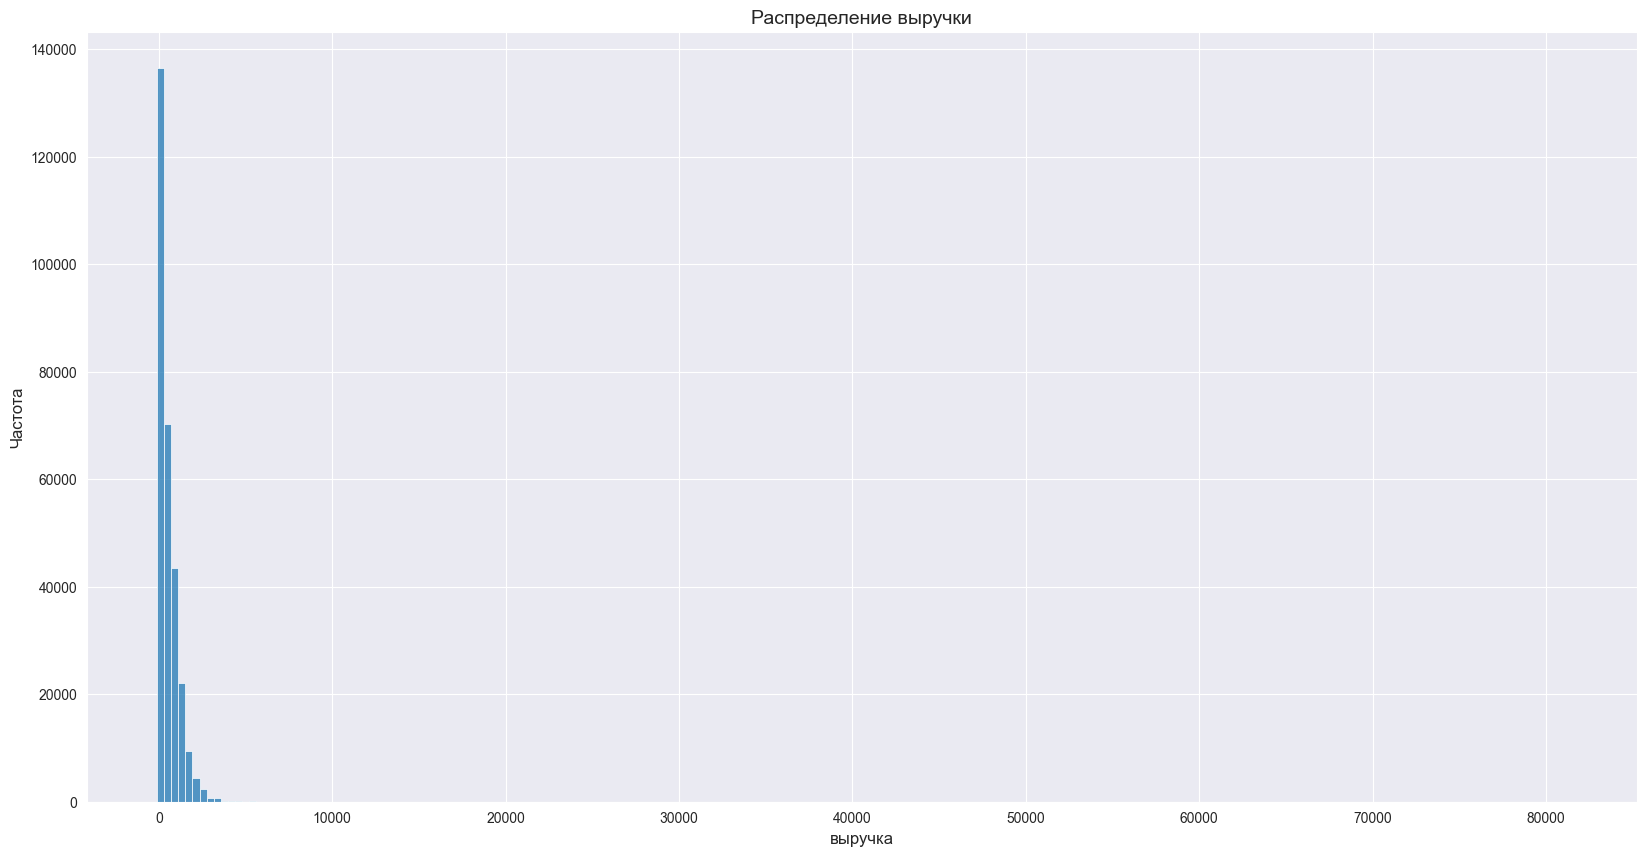

In [33]:
plt.figure(figsize=(20, 10))
sns.histplot(df['revenue_rub'], bins=200)
plt.title('Распределение выручки', fontsize=14)
plt.xlabel('выручка', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.show()

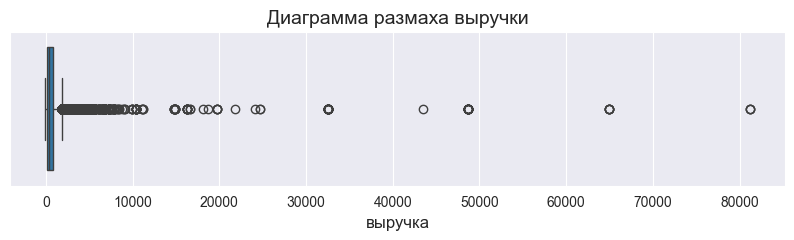

In [34]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['revenue_rub'])
plt.title('Диаграмма размаха выручки', fontsize=14)
plt.xlabel('выручка', fontsize=12)
plt.show()

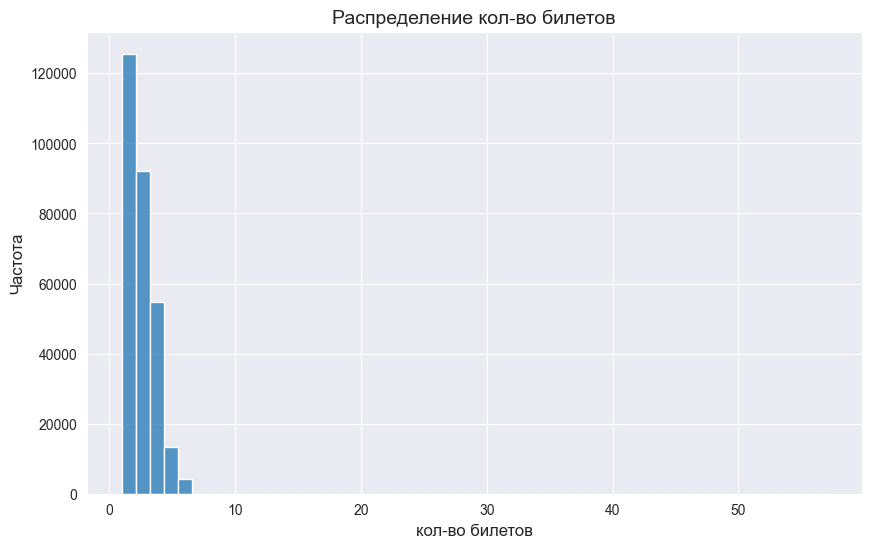

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(df['tickets_count'], bins=50)
plt.title('Распределение кол-во билетов', fontsize=14)
plt.xlabel('кол-во билетов', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.show()

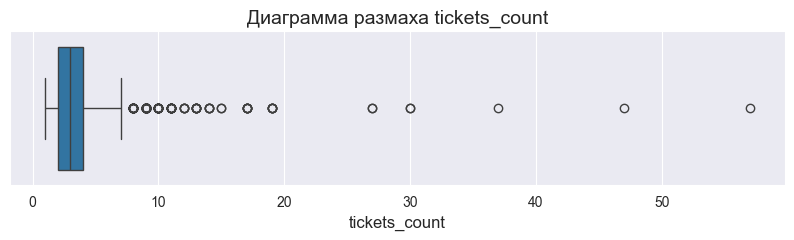

In [36]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['tickets_count'])
plt.title('Диаграмма размаха tickets_count', fontsize=14)
plt.xlabel('tickets_count', fontsize=12)
plt.show()

In [37]:
percentile_99 = df['revenue_rub'].quantile(0.99)
print(f"99 перцентиль revenue_rub: {percentile_99:.2f}")

# Количество выбросов до фильтрации
outliers_before = df[df['revenue_rub'] > percentile_99].shape[0]
print(f"Количество выбросов до фильтрации: {outliers_before}")

# Фильтруем данные
df_cleaned = df[df['revenue_rub'] <= percentile_99].copy()

99 перцентиль revenue_rub: 2628.42
Количество выбросов до фильтрации: 2825


In [38]:
rows_before = df.shape[0]
rows_after = df_cleaned.shape[0]
rows_filtered = rows_before - rows_after
print(f"Строк до фильтрации: {rows_before}")
print(f"Строк после фильтрации: {rows_after}")
print(f"Отфильтровано строк: {rows_filtered}")
print(f"Доля отфильтрованных данных: {rows_filtered / rows_before * 100:.2f}%")

Строк до фильтрации: 290611
Строк после фильтрации: 287786
Отфильтровано строк: 2825
Доля отфильтрованных данных: 0.97%


In [39]:
df = df_cleaned

<h3>Промежуточный вывод</h3>
<br>Нормализация данных не требуется. Проведено преобразование типов данных для полей с типом устройства, кодом валюты, и типом меропрития в категориальные данные. А также для поля с количеством дней с последнего заказа - в целочисленный. Пропусков кроме поля с количеством дней мы не имеем.

<br>По распределению данных:
<br>Количество билетов варьируется от 1 до 57. При этом 57 билетов - сильный выброс, учитывая что 99 процентиль - это 6 билетов. Медиана 3 билета - в принципе, типичный заказ. 90% заказов содержит до 4 билетов - что говорит о хорошей концетрации данных.
<br>Выручка:
<br>Первое на что стоит обратить внимание - отрицательные значения (-90,76 минимальное значение). Возможно, возвраты, либо ошибки. Сильный перекос вправо: среднее (555.57) больше медианы (351.14) — есть крупные выбросы. Экстремальные выбросы: максимум 81 174 руб при 99 перцентиле 2 628 руб — явные аномалии. Большая часть данных (75%) сосредоточена до 802 руб.

<br>В итоге мы отфильтровали фрейм по 99 процентилю выручки. По итогу потеряли 0,97% данных (2825 строк было отфильтровано).

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [40]:
df = df.sort_values(['user_id', 'created_ts_msk'])

In [41]:
# Сформируем профили пользователей
user_profile = df.groupby('user_id').agg(
                          first_order_date=('created_dt_msk', 'min'), last_order_date=('created_dt_msk', 'max'),
                          device=('device_type_canonical', lambda r: r.iloc[0]),
                          region=('region_name', lambda r: r.iloc[0]),
                          service=('service_name', lambda r: r.iloc[0]),
                          first_event=('event_type_main', lambda r: r.iloc[0]),
                          total_ord=('order_id', 'count'),
                          avg_revenue_ord=('revenue_rub', 'mean'),
                          avg_tickets_ord=('tickets_count', 'mean'),
                          time_between_ord=('created_dt_msk', lambda r: r.diff().mean()),
                          is_two=('order_id', lambda r: True if len(r) >= 2 else False),
                          is_five=('order_id', lambda r: True if len(r) >= 5 else False)
                          ).reset_index()

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [42]:
#всего пользователей
user_profile['user_id'].count()

np.int64(21854)

In [43]:
#средняя выручка с одного заказа
user_profile['avg_revenue_ord'].mean()

np.float64(544.398050897431)

In [44]:
#среднее число билетов в заказе
user_profile['avg_tickets_ord'].mean()

np.float64(2.7431289886335195)

In [45]:
user_profile['time_between_ord'] = user_profile['time_between_ord'].dt.days
#среднее количество дней между заказами
user_profile['time_between_ord'].mean()

np.float64(15.624647782885956)

In [46]:
print("Статистика по общему числу заказов:")
print(user_profile['total_ord'].describe(percentiles=[0.95, 0.99]))

print("\nСтатистика по среднему числу билетов в заказе:")
print(user_profile['avg_tickets_ord'].describe(percentiles=[0.95, 0.99]))

# Только для пользователей с 2+ заказами
users_2plus = user_profile[user_profile['is_two'] == True]
print("\nСтатистика по среднему количеству дней между покупками:")
print(users_2plus['time_between_ord'].describe(percentiles=[0.95, 0.99]))

Статистика по общему числу заказов:
count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
95%         31.350000
99%        152.000000
max      10181.000000
Name: total_ord, dtype: float64

Статистика по среднему числу билетов в заказе:
count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_ord, dtype: float64

Статистика по среднему количеству дней между покупками:
count    13486.000000
mean        15.624648
std         22.307475
min          0.000000
95%         61.000000
99%        112.000000
max        148.000000
Name: time_between_ord, dtype: float64


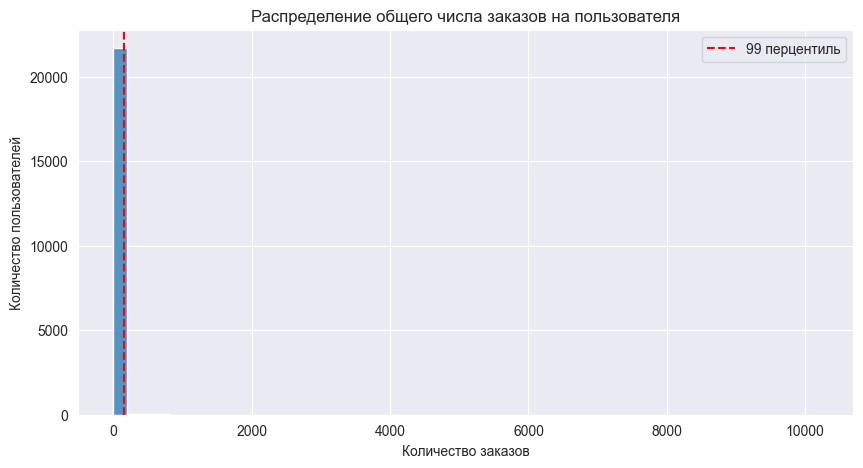

In [47]:
plt.figure(figsize=(10, 5))
sns.histplot(user_profile['total_ord'], bins=50)
plt.title('Распределение общего числа заказов на пользователя')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')
plt.axvline(x=user_profile['total_ord'].quantile(0.99), color='red', linestyle='--', label='99 перцентиль')
plt.legend()
plt.show()

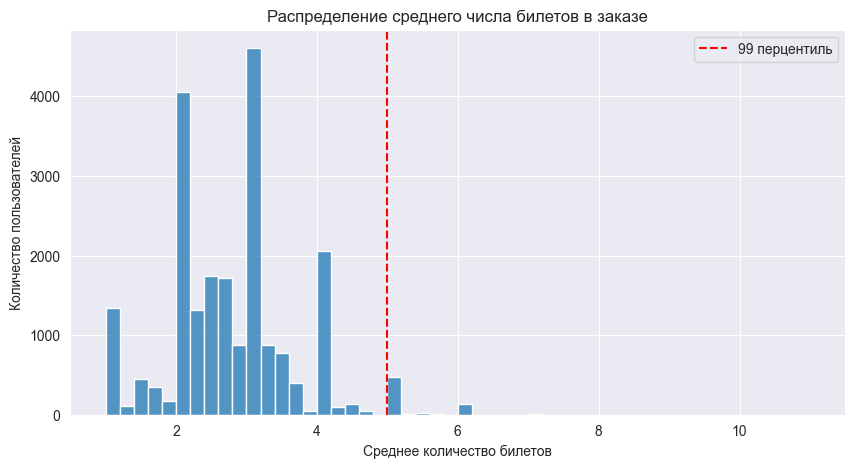

In [48]:
plt.figure(figsize=(10, 5))
sns.histplot(user_profile['avg_tickets_ord'], bins=50)
plt.title('Распределение среднего числа билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.axvline(x=user_profile['avg_tickets_ord'].quantile(0.99), color='red', linestyle='--', label='99 перцентиль')
plt.legend()
plt.show()

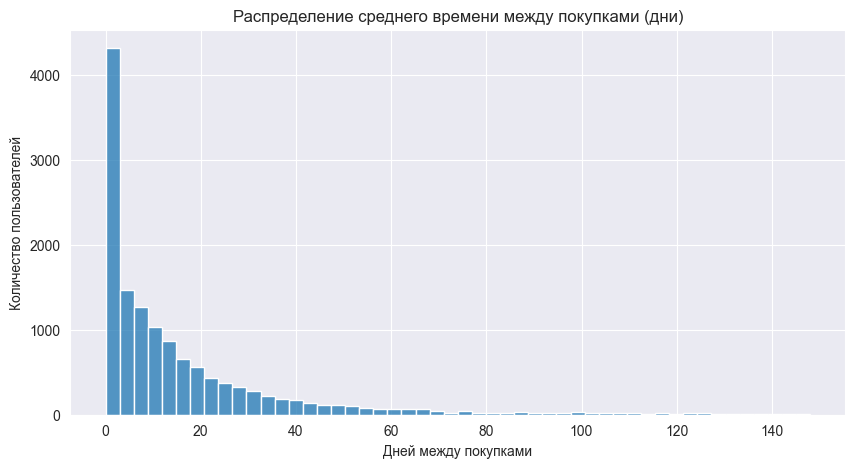

In [49]:
plt.figure(figsize=(10, 5))
sns.histplot(users_2plus['time_between_ord'].dropna(), bins=50)
plt.title('Распределение среднего времени между покупками (дни)')
plt.xlabel('Дней между покупками')
plt.ylabel('Количество пользователей')
plt.show()

Общее число заказов: <br>
Аномалия: максимум 10 181 заказ при 99 перцентиле = 152

Проблема: среднее (13.2) сильно ниже максимума, значит есть единичные "супер-пользователи"

Решение: фильтруем по 99 перцентилю (152 заказа)


Среднее число билетов<br>
Аномалий нет: 99 перцентиль = 5, максимум = 11 — разумно

Решение: оставляем как есть

Дни между покупками <br>
Аномалий нет: 99 перцентиль = 112 дней (3.7 месяца), максимум = 148 дней (~5 месяцев)

Нюанс: есть 0 дней (покупки в один день) — нормально

Решение: оставляем как есть

In [50]:
p99_orders = user_profile['total_ord'].quantile(0.99)

user_profile_clean = user_profile[user_profile['total_ord'] <= p99_orders].copy()

print(f"Пользователей до: {len(user_profile):,}")
print(f"Пользователей после: {len(user_profile_clean):,}")
print(f"Отфильтровано: {len(user_profile) - len(user_profile_clean):,} ({(1 - len(user_profile_clean)/len(user_profile))*100:.2f}%)")
user_profile = user_profile_clean
del user_profile_clean
del users_2plus

Пользователей до: 21,854
Пользователей после: 21,638
Отфильтровано: 216 (0.99%)


---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


Распределение по типу первого мероприятия:
             Количество пользователей  Доля (%)
first_event                                    
концерты                         9560     44.18
другое                           5426     25.08
театр                            4239     19.59
стендап                          1110      5.13
спорт                             794      3.67
выставки                          414      1.91
ёлки                               95      0.44


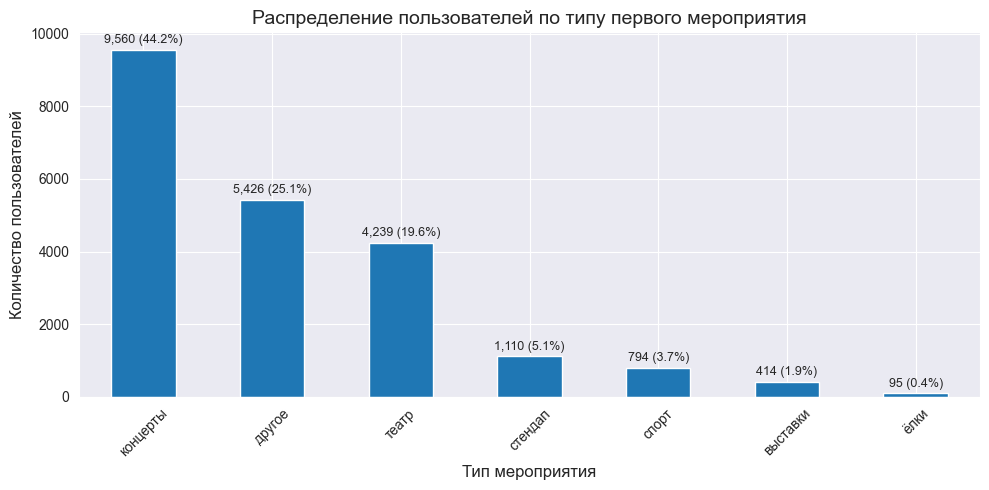

In [51]:
# Группировка по first_event
event_dist = user_profile['first_event'].value_counts()
event_pct = user_profile['first_event'].value_counts(normalize=True) * 100

event_df = pd.DataFrame({
    'Количество пользователей': event_dist,
    'Доля (%)': event_pct.round(2)
})
print("Распределение по типу первого мероприятия:")
print(event_df)

plt.figure(figsize=(10, 5))
ax = event_dist.plot(kind='bar')
plt.title('Распределение пользователей по типу первого мероприятия', fontsize=14)
plt.xlabel('Тип мероприятия', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45)


for i, (bar, count, pct) in enumerate(zip(ax.patches, event_dist.values, event_pct.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(event_dist)*0.01,
            f'{count:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Сильная неравномерность. Концерты — доминирующая точка входа (почти половина пользователей). В сумме концерты + театр дают 63.77% аудитории.


Распределение по типу устройства:
         Количество пользователей  Доля (%)
device                                     
mobile                      17924     82.84
desktop                      3714     17.16


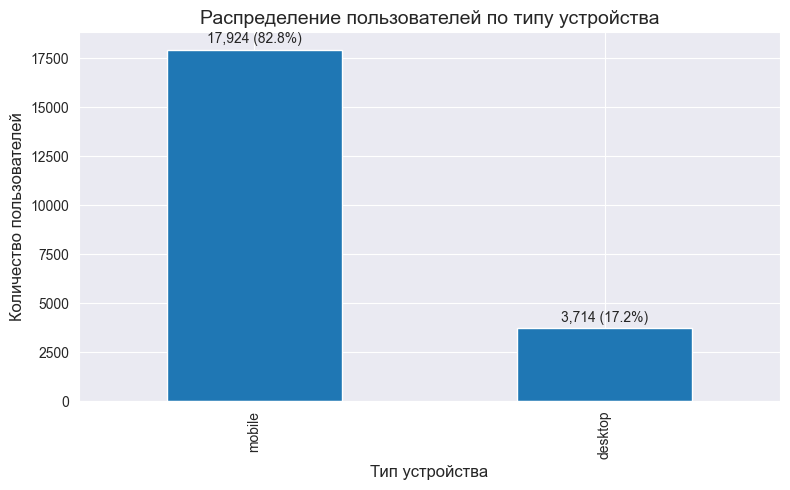

In [52]:
# Группировка по device
device_dist = user_profile['device'].value_counts()
device_pct = user_profile['device'].value_counts(normalize=True) * 100

device_df = pd.DataFrame({
    'Количество пользователей': device_dist,
    'Доля (%)': device_pct.round(2)
})
print("\nРаспределение по типу устройства:")
print(device_df)

# Визуализация с подписями (число + %)
plt.figure(figsize=(8, 5))
ax = device_dist.plot(kind='bar')
plt.title('Распределение пользователей по типу устройства', fontsize=14)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)

# Добавляем подписи данных: число (доля %)
for bar, count, pct in zip(ax.patches, device_dist.values, device_pct.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(device_dist)*0.01,
            f'{count:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Крайняя неравномерность. Мобильные устройства — абсолютный канал привлечения (почти 83% первых покупок). Десктоп — второстепенный.

Распределение по регионам:
                          Количество пользователей  Доля (%)
region                                                      
Каменевский регион                            7085     32.74
Североярская область                          3767     17.41
Широковская область                           1224      5.66
Озернинский край                               675      3.12
Малиновоярский округ                           525      2.43
...                                            ...       ...
Светолесский край                                2      0.01
Тихогорская область                              2      0.01
Сосноводолинская область                         1      0.00
Яснопольский округ                               1      0.00
Верхозёрский край                                1      0.00

[81 rows x 2 columns]


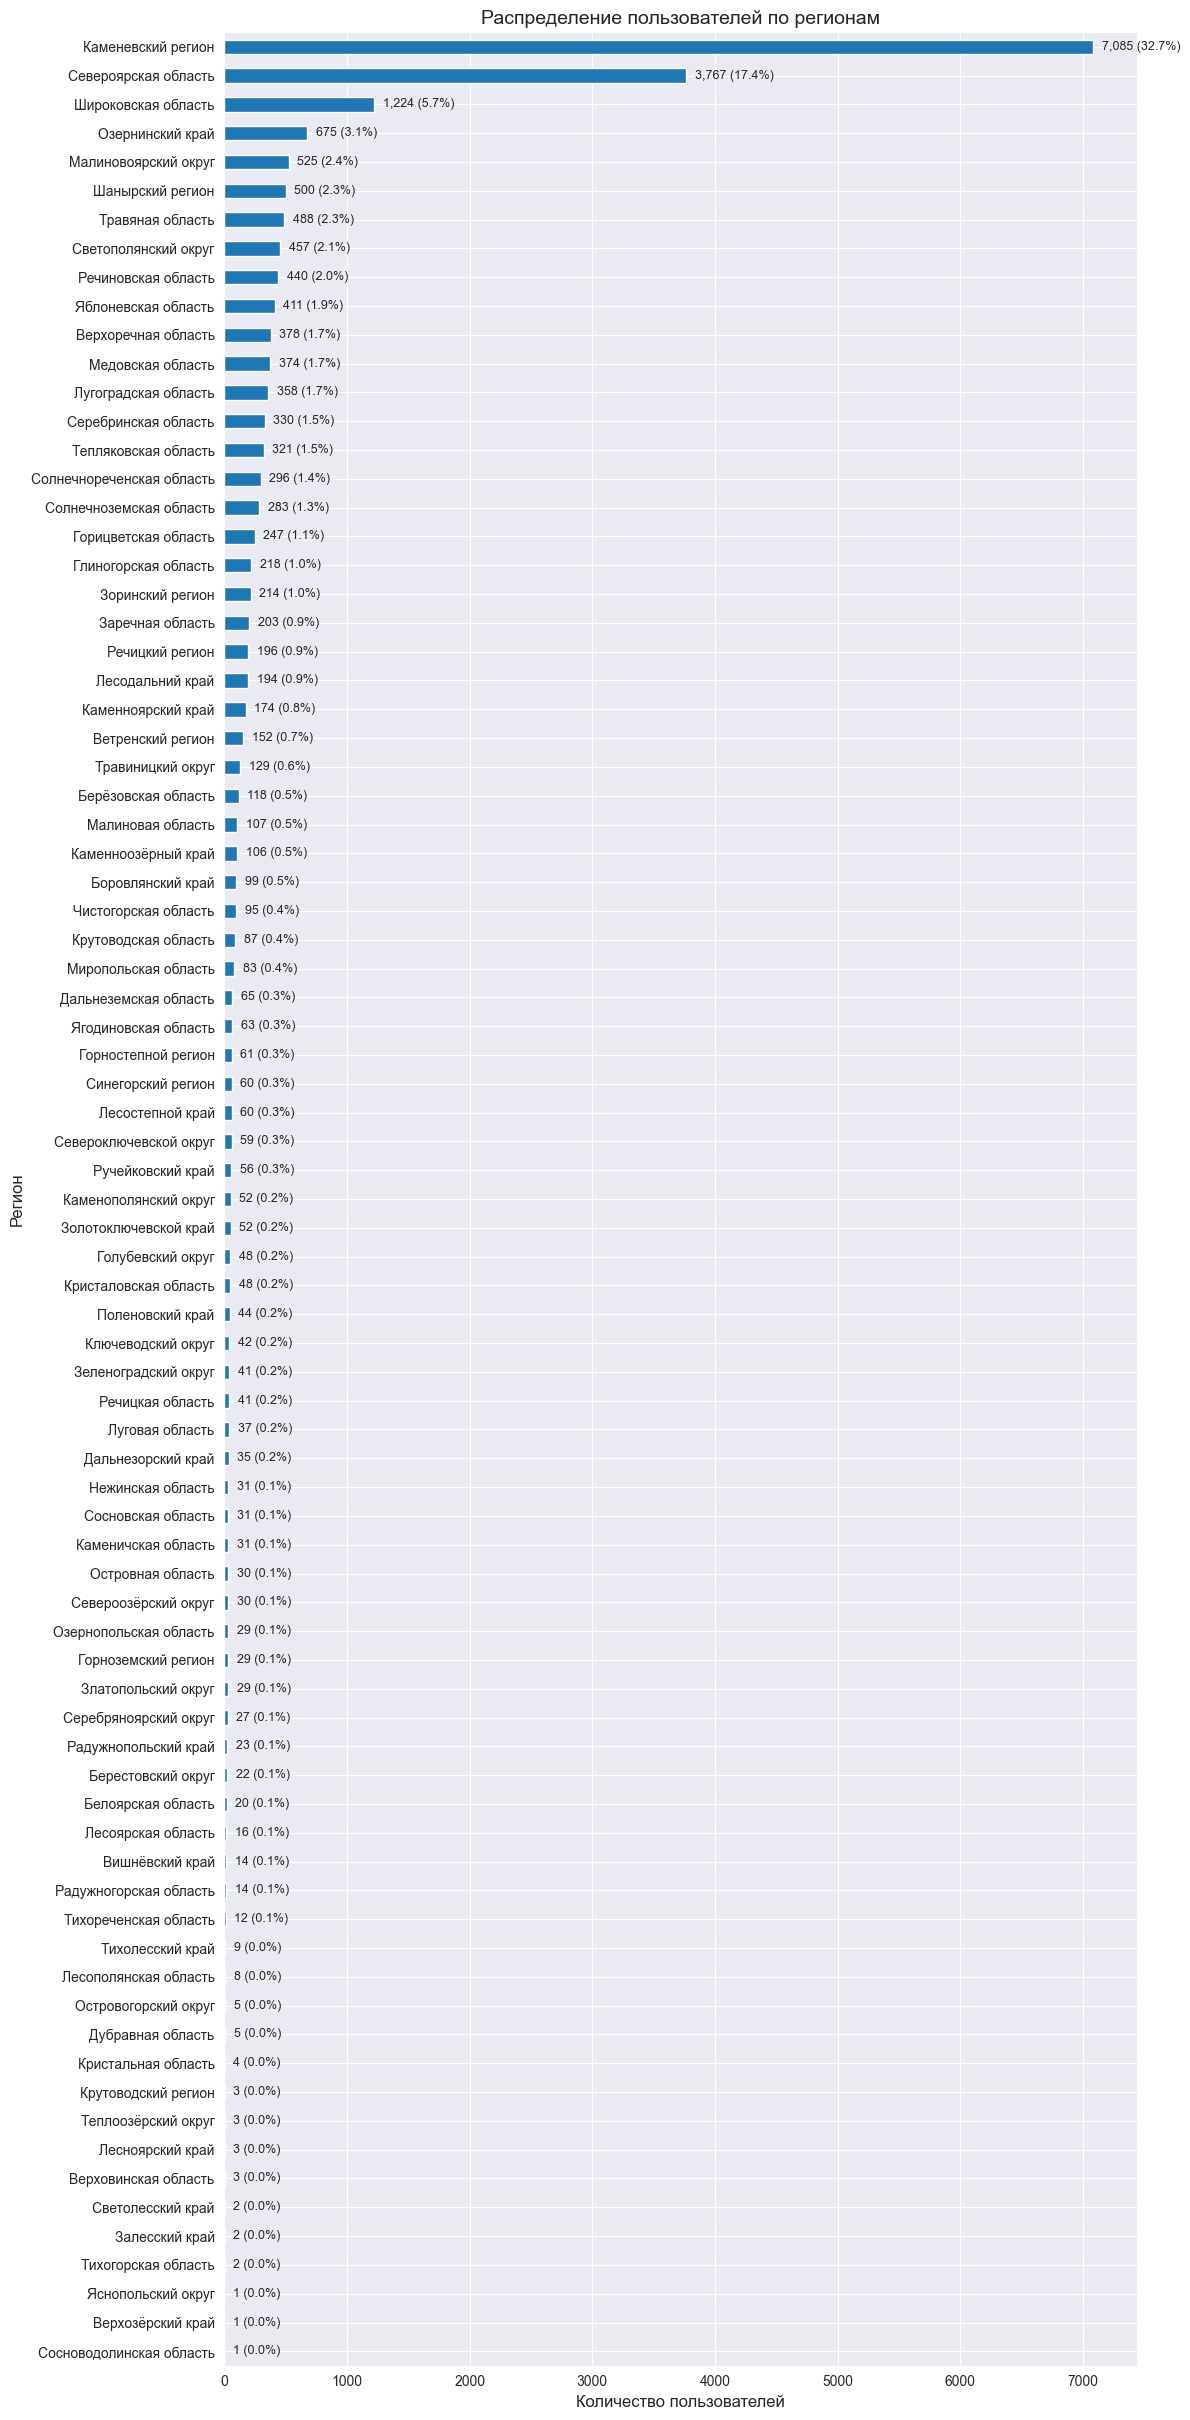

In [53]:
# Группировка по region
region_dist = user_profile['region'].value_counts()
region_pct = user_profile['region'].value_counts(normalize=True) * 100

region_df = pd.DataFrame({
    'Количество пользователей': region_dist,
    'Доля (%)': region_pct.round(2)
})
print("Распределение по регионам:")
print(region_df)


plt.figure(figsize=(12, max(8, len(region_dist) * 0.3)))
ax = region_dist.sort_values(ascending=True).plot(kind='barh')
plt.title('Распределение пользователей по регионам', fontsize=14)
plt.xlabel('Количество пользователей', fontsize=12)
plt.ylabel('Регион', fontsize=12)


for bar in ax.patches:
    width = bar.get_width()
    region = bar.get_y()


for i, (region, count) in enumerate(region_dist.sort_values(ascending=True).items()):
    bar = ax.patches[i]
    pct = region_pct[region]
    ax.text(bar.get_width() + max(region_dist)*0.01,
            bar.get_y() + bar.get_height()/2.,
            f'{count:,} ({pct:.1f}%)',
            ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Сильная концентрация. Топ-2 региона дают 50.14% всех пользователей. Топ-1 регион (Каменевский) — каждый третий пользователь. Много регионов с единичными пользователями.

Распределение по билетному оператору:
                        Количество пользователей  Доля (%)
service                                                   
Билеты без проблем                          5186     23.97
Мой билет                                   2969     13.72
Лови билет!                                 2809     12.98
Билеты в руки                               2559     11.83
Облачко                                     2177     10.06
Весь в билетах                              1285      5.94
Лучшие билеты                               1184      5.47
Прачечная                                    583      2.69
Край билетов                                 454      2.10
Дом культуры                                 356      1.65
Яблоко                                       318      1.47
Тебе билет!                                  308      1.42
Городской дом культуры                       215      0.99
Мир касс                                     209      0.97
За билетом!       

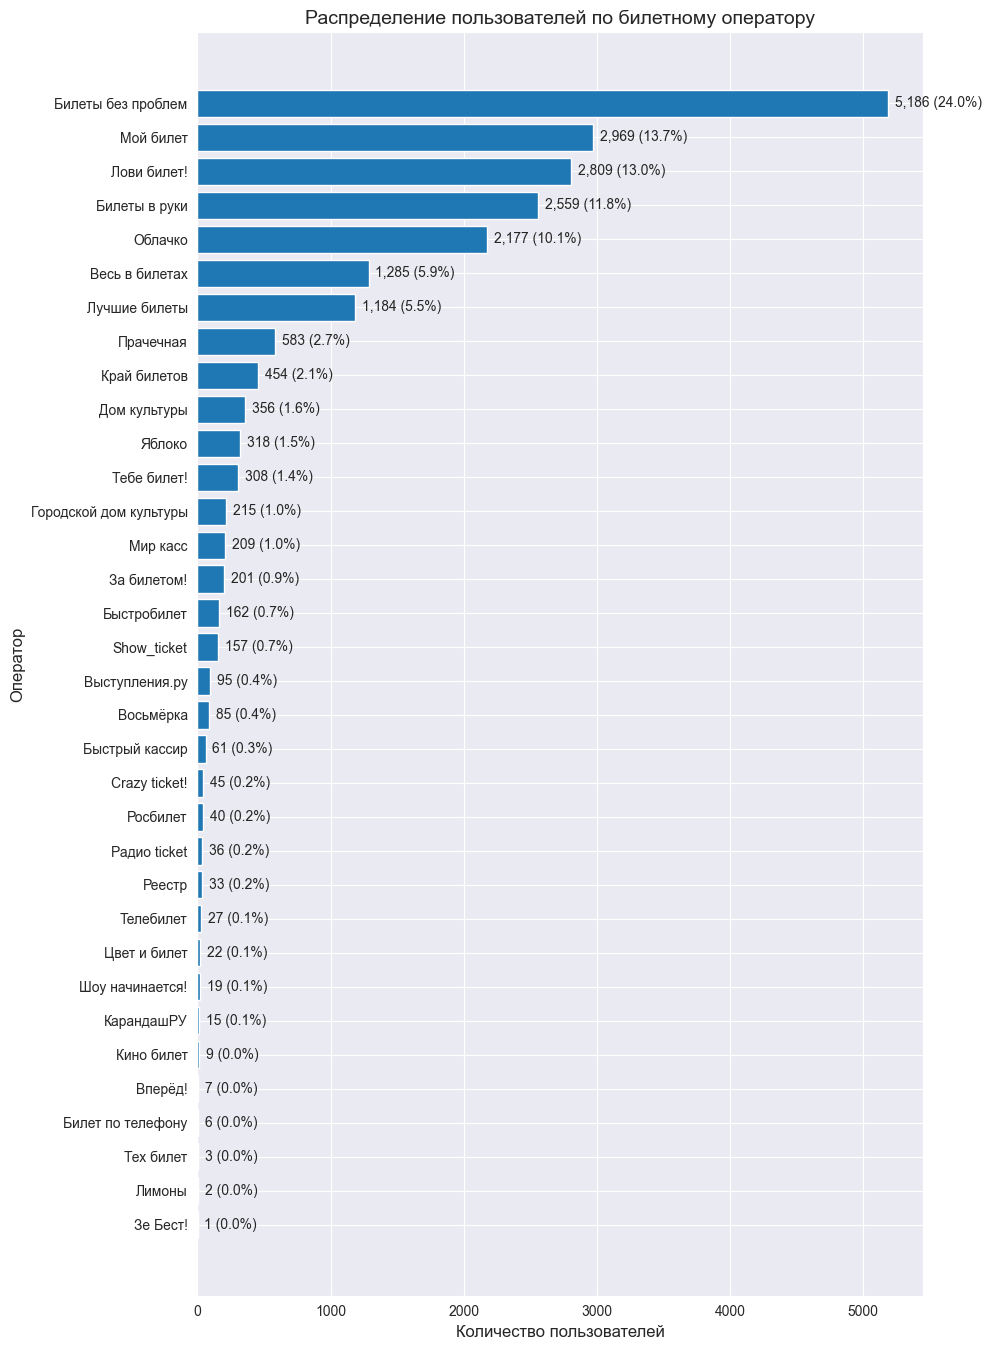

In [54]:
# Группировка по service
service_dist = user_profile['service'].value_counts()
service_pct = user_profile['service'].value_counts(normalize=True) * 100

service_df = pd.DataFrame({
    'Количество пользователей': service_dist,
    'Доля (%)': service_pct.round(2)
})
print("Распределение по билетному оператору:")
print(service_df)


service_dist_sorted = service_dist.sort_values(ascending=True)
service_pct_sorted = service_pct[service_dist_sorted.index]


plt.figure(figsize=(10, max(6, len(service_dist) * 0.4)))
bars = plt.barh(service_dist_sorted.index, service_dist_sorted.values)
plt.title('Распределение пользователей по билетному оператору', fontsize=14)
plt.xlabel('Количество пользователей', fontsize=12)
plt.ylabel('Оператор', fontsize=12)

# Добавляем подписи данных: число (доля %)
for bar, (service, count) in zip(bars, service_dist_sorted.items()):
    pct = service_pct[service]
    plt.text(bar.get_width() + max(service_dist)*0.01,
             bar.get_y() + bar.get_height()/2.,
             f'{count:,} ({pct:.1f}%)',
             ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Умеренная неравномерность. Топ-1 оператор — почти четверть пользователей. Топ-5 операторов покрывают 72.56% аудитории. Остальные 30+ операторов делят оставшиеся ~27%.

<h3>Выводы</h3>
<table>
  <thead>
    <tr>
      <th>Признак</th>
      <th>Равномерность</th>
      <th>Точка входа</th>
      <th>Доля лидера</th>
     </tr>
  </thead>
  <tbody>
    <tr>
      <td>Тип мероприятия</td>
      <td>неравномерно</td>
      <td>концерты</td>
      <td>44.1%</td>
     </tr>
    <tr>
      <td>Тип устройства</td>
      <td>крайне неравномерно</td>
      <td>mobile</td>
      <td>82.9%</td>
     </tr>
    <tr>
      <td>Регион</td>
      <td>неравномерно</td>
      <td>Каменевский регион</td>
      <td>32.8%</td>
     </tr>
    <tr>
      <td>Оператор</td>
      <td>умеренно неравномерно</td>
      <td>Билеты без проблем</td>
      <td>24.0%</td>
     </tr>
  </tbody>
</table>



Выраженные «точки входа»:

Мобильные устройства — абсолютный канал (83%)

Концерты — основной тип первого мероприятия (44%)

Каменевский регион — ключевой географический источник (33%)

Билеты без проблем — ведущий оператор (24%)

Рекомендация: Маркетинговые усилия стоит фокусировать на этих сегментах, но также обратить внимание на недоиспользованные каналы (десктоп, театры, другие регионы, операторы с долей 10-15%).

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Доля возвратов по типу устройства:
    device  users  return_users  return_rate_pct
0  desktop   3714          2370        63.812601
1   mobile  17924         10900        60.812319


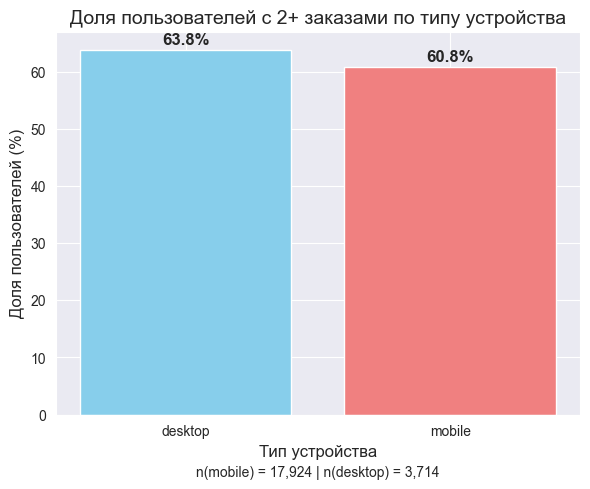

In [55]:
return_by_device = user_profile.groupby('device').agg(
    users=('user_id', 'count'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
).reset_index()
return_by_device['return_rate_pct'] = return_by_device['return_rate'] * 100
return_by_device = return_by_device.sort_values('return_rate', ascending=False)

print("Доля возвратов по типу устройства:")
print(return_by_device[['device', 'users', 'return_users', 'return_rate_pct']])

# Визуализация
plt.figure(figsize=(6, 5))
bars = plt.bar(return_by_device['device'], return_by_device['return_rate_pct'],
               color=['skyblue', 'lightcoral'])
plt.title('Доля пользователей с 2+ заказами по типу устройства', fontsize=14)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Доля пользователей (%)', fontsize=12)


for bar, val in zip(bars, return_by_device['return_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')


plt.text(0.5, -0.15, f'n(mobile) = {return_by_device[return_by_device["device"]=="mobile"]["users"].values[0]:,} | n(desktop) = {return_by_device[return_by_device["device"]=="desktop"]["users"].values[0]:,}',
         ha='center', va='center', transform=plt.gca().transAxes, fontsize=10)

plt.tight_layout()
plt.show()


Доля возвратов по типу первого мероприятия:
  first_event  users  return_users  return_rate_pct
0    выставки    414           265        64.009662
5       театр   4239          2687        63.387591
2    концерты   9560          5911        61.830544
4     стендап   1110           676        60.900901
1      другое   5426          3235        59.620346
3       спорт    794           443        55.793451
6        ёлки     95            53        55.789474


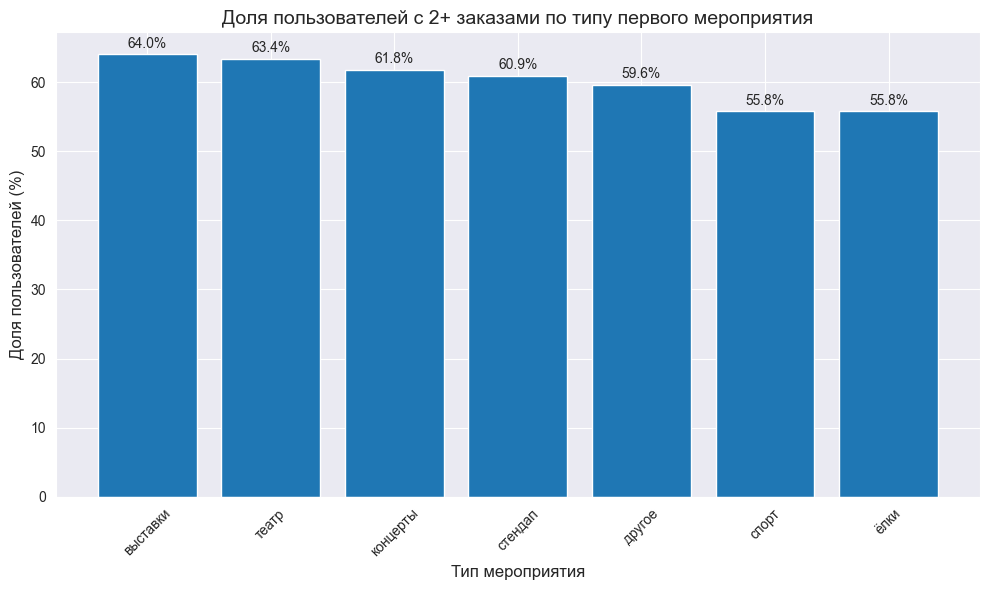

In [56]:
return_by_event = user_profile.groupby('first_event').agg(
    users=('user_id', 'count'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
).reset_index()
return_by_event['return_rate_pct'] = return_by_event['return_rate'] * 100
return_by_event = return_by_event.sort_values('return_rate', ascending=False)

print("\nДоля возвратов по типу первого мероприятия:")
print(return_by_event[['first_event', 'users', 'return_users', 'return_rate_pct']])

# Визуализация
plt.figure(figsize=(10, 6))
bars = plt.bar(return_by_event['first_event'], return_by_event['return_rate_pct'])
plt.title('Доля пользователей с 2+ заказами по типу первого мероприятия', fontsize=14)
plt.xlabel('Тип мероприятия', fontsize=12)
plt.ylabel('Доля пользователей (%)', fontsize=12)
plt.xticks(rotation=45)

for bar, val in zip(bars, return_by_event['return_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


Доля возвратов по регионам (топ-10):
                  region  users  return_users  return_rate_pct
76      Шанырский регион    500           336        67.200000
57  Светополянский округ    457           300        65.645514
77   Широковская область   1224           790        64.542484
60  Североярская область   3767          2404        63.817361
52   Речиновская область    440           279        63.409091
23    Каменевский регион   7085          4421        62.399435
74      Травяная область    488           300        61.475410
78   Яблоневская область    411           244        59.367397
41  Малиновоярский округ    525           294        56.000000
45      Озернинский край    675           373        55.259259


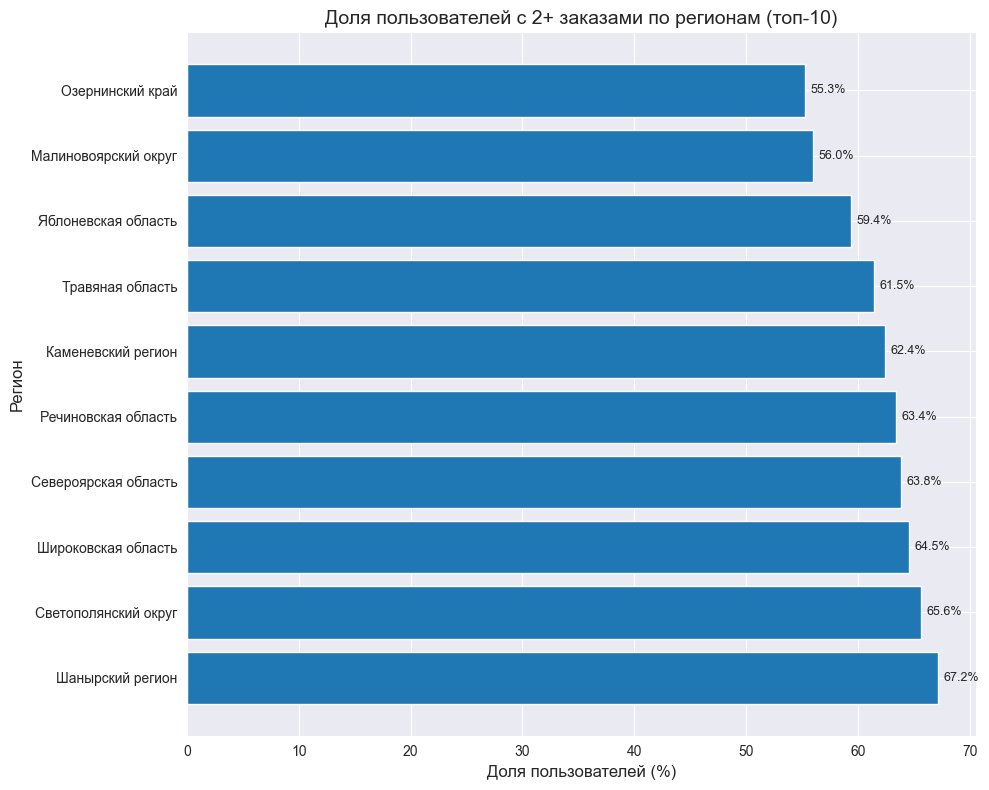

In [57]:
return_by_region = user_profile.groupby('region').agg(
    users=('user_id', 'count'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
).reset_index()
return_by_region['return_rate_pct'] = return_by_region['return_rate'] * 100

top_regions = return_by_region.nlargest(10, 'users')
top_regions = top_regions.sort_values('return_rate', ascending=False)

print("\nДоля возвратов по регионам (топ-10):")
print(top_regions[['region', 'users', 'return_users', 'return_rate_pct']])

# Визуализация
plt.figure(figsize=(10, 8))
bars = plt.barh(top_regions['region'], top_regions['return_rate_pct'])
plt.title('Доля пользователей с 2+ заказами по регионам (топ-10)', fontsize=14)
plt.xlabel('Доля пользователей (%)', fontsize=12)
plt.ylabel('Регион', fontsize=12)

for bar, val in zip(bars, top_regions['return_rate_pct']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2.,
             f'{val:.1f}%', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()


Доля возвратов по билетным операторам (топ-10):
               service  users  return_users  return_rate_pct
17        Край билетов    454           296        65.198238
12        Дом культуры    356           230        64.606742
7       Весь в билетах   1285           808        62.879377
4        Билеты в руки   2559          1605        62.719812
24           Прачечная    583           365        62.607204
23             Облачко   2177          1334        61.276987
20       Лучшие билеты   1184           725        61.233108
19         Лови билет!   2809          1711        60.911356
22           Мой билет   2969          1807        60.862243
3   Билеты без проблем   5186          3133        60.412649


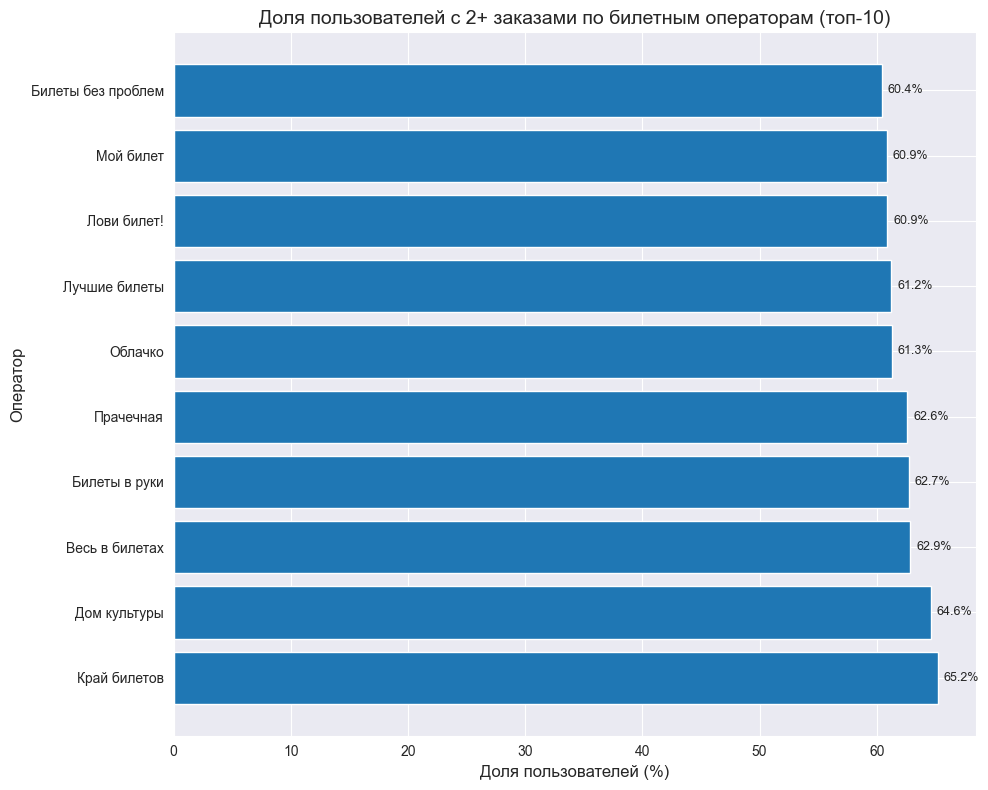

In [58]:
return_by_service = user_profile.groupby('service').agg(
    users=('user_id', 'count'),
    return_users=('is_two', 'sum'),
    return_rate=('is_two', 'mean')
).reset_index()
return_by_service['return_rate_pct'] = return_by_service['return_rate'] * 100

top_services = return_by_service.nlargest(10, 'users')
top_services = top_services.sort_values('return_rate', ascending=False)

print("\nДоля возвратов по билетным операторам (топ-10):")
print(top_services[['service', 'users', 'return_users', 'return_rate_pct']])

# Визуализация
plt.figure(figsize=(10, 8))
bars = plt.barh(top_services['service'], top_services['return_rate_pct'])
plt.title('Доля пользователей с 2+ заказами по билетным операторам (топ-10)', fontsize=14)
plt.xlabel('Доля пользователей (%)', fontsize=12)
plt.ylabel('Оператор', fontsize=12)

for bar, val in zip(bars, top_services['return_rate_pct']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2.,
             f'{val:.1f}%', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

<h3>Выводы</h3>
Десктопные пользователи возвращаются чаще, хотя их аудитория в 4.8 раза меньше мобильной. Это более лояльный, но меньший по размеру сегмент.
Выставки и театр — самые лояльные сегменты (возврат >63%)

Спорт и ёлки — наименее лояльные (возврат ~55-56%)

Концерты — крупнейший сегмент (9 560 чел.) с хорошей лояльностью (61.8%)

Шанырский регион — самый лояльный (67.2%), но средний по размеру (500 чел.)

Каменевский регион — крупнейший (7 085 чел.) с хорошей лояльностью (62.4%)

Разброс между регионами: от 55% до 67%

Край билетов и Дом культуры — самые лояльные операторы (>64.5%)

Билеты без проблем — крупнейший оператор (5 186 чел.) с лояльностью чуть выше 60%

Разброс среди топ-10: от 60.4% до 65.2%

<h4>Тезисно: </h4>

Десктоп — недооценённый канал с высокой лояльностью (63.8%), хотя доля аудитории мала (17%)

Выставки и театр — точки входа с самой высокой повторной покупкой (>63%)

Шанырский регион — аномально высокий возврат (67.2%), стоит изучить локальные практики

Край билетов и Дом культуры — операторы с наилучшей удержанием клиентов

Спорт и ёлки — проблемные сегменты с низким возвратом (~55%)

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

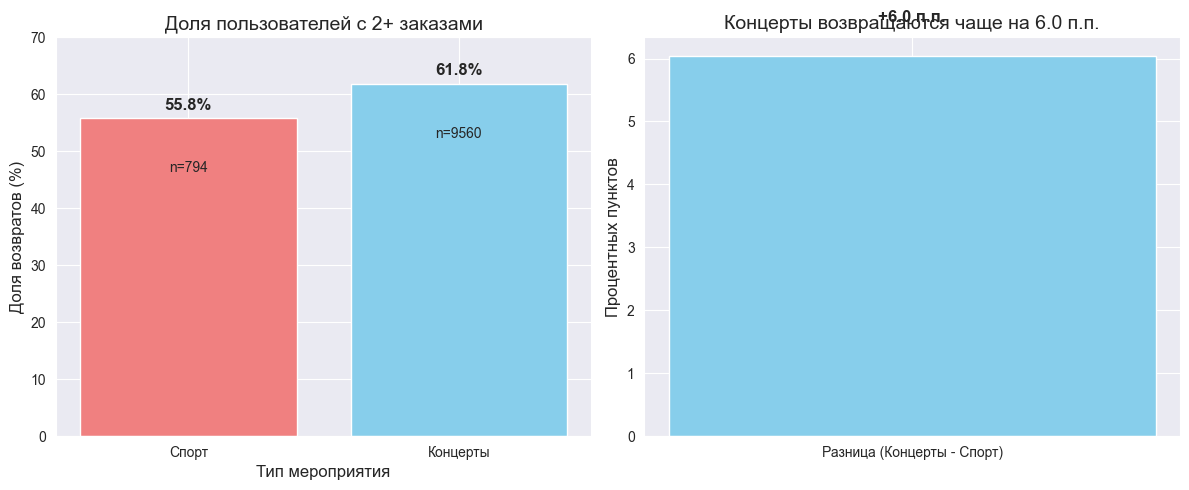

In [59]:
categories = ['Спорт', 'Концерты']
return_rates = [55.79, 61.83]
users = [794, 9560]

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График 1: Сравнение долей возвратов
bars = ax1.bar(categories, return_rates, color=['lightcoral', 'skyblue'])
ax1.set_ylim(0, 70)
ax1.set_title('Доля пользователей с 2+ заказами', fontsize=14)
ax1.set_ylabel('Доля возвратов (%)', fontsize=12)
ax1.set_xlabel('Тип мероприятия', fontsize=12)

for bar, val in zip(bars, return_rates):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() - 10,
             f'n={users[0] if val==55.79 else users[1]}',
             ha='center', va='bottom', fontsize=10)

# График 2: Разница
diff = 61.83 - 55.79
colors_diff = ['lightcoral' if diff < 0 else 'skyblue']
bars2 = ax2.bar(['Разница (Концерты - Спорт)'], [diff], color=colors_diff)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_ylabel('Процентных пунктов', fontsize=12)
ax2.set_title(f'Концерты возвращаются чаще на {diff:.1f} п.п.', fontsize=14)

for bar, val in zip(bars2, [diff]):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'+{val:.1f} п.п.', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Гипотезу о том, что пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты - опровергаем

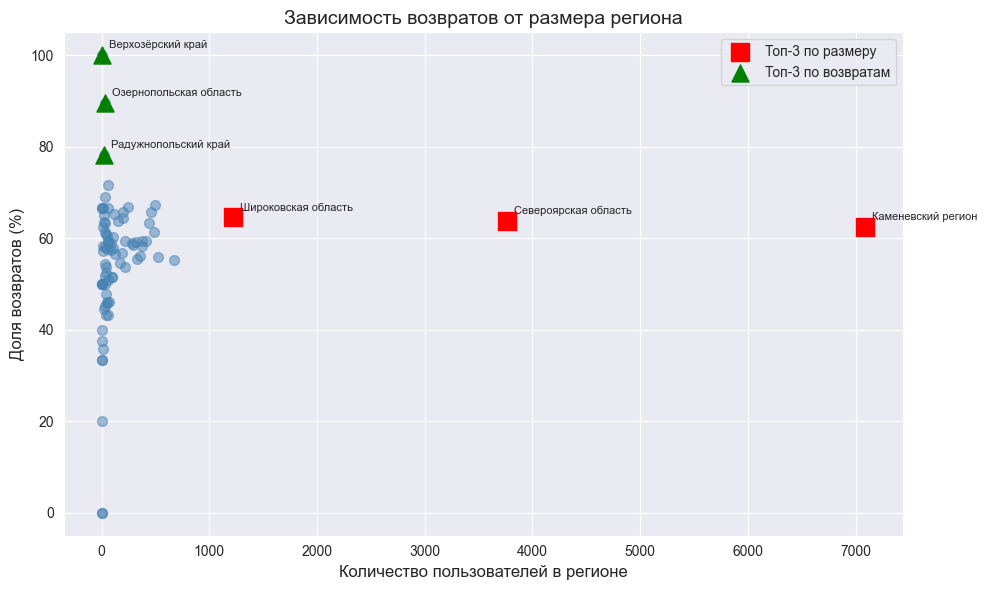

In [60]:
plt.figure(figsize=(10, 6))
plt.scatter(return_by_region['users'], return_by_region['return_rate_pct'],
            alpha=0.5, s=50, c='steelblue')

# Выделяем топ-3 по размеру и топ-3 по возвратам
top3_size = return_by_region.nlargest(3, 'users')
top3_return = return_by_region.nlargest(3, 'return_rate')

plt.scatter(top3_size['users'], top3_size['return_rate_pct'],
            color='red', s=150, marker='s', label='Топ-3 по размеру')
plt.scatter(top3_return['users'], top3_return['return_rate_pct'],
            color='green', s=150, marker='^', label='Топ-3 по возвратам')

plt.xlabel('Количество пользователей в регионе', fontsize=12)
plt.ylabel('Доля возвратов (%)', fontsize=12)
plt.title('Зависимость возвратов от размера региона', fontsize=14)

# Добавляем подписи для выделенных регионов
for _, row in top3_size.iterrows():
    plt.annotate(row['region'], (row['users'], row['return_rate_pct']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

for _, row in top3_return.iterrows():
    plt.annotate(row['region'], (row['users'], row['return_rate_pct']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

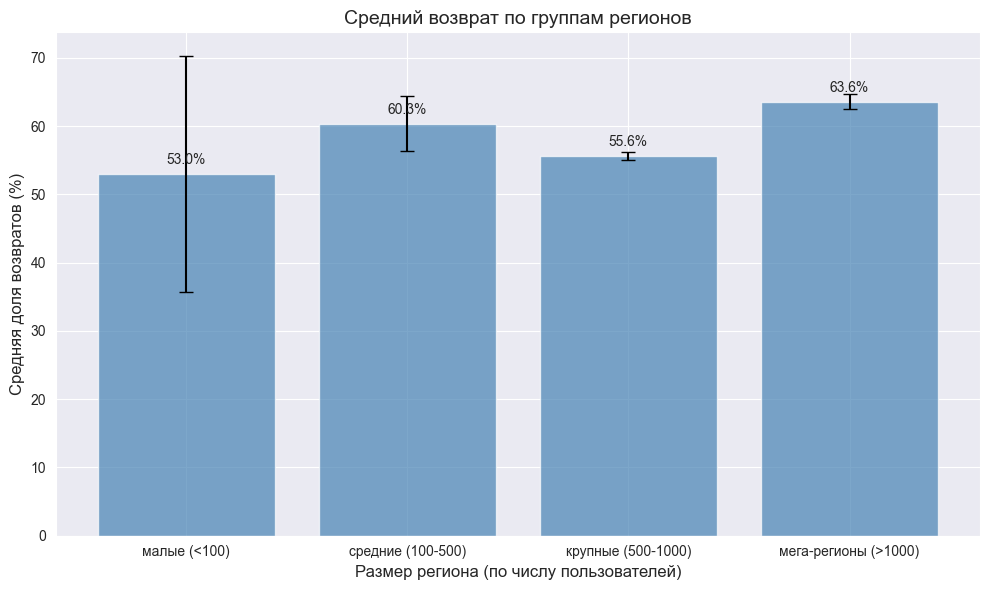

In [61]:
region_by_size = return_by_region.copy()
region_by_size['size_group'] = pd.cut(region_by_size['users'],
                                       bins=[0, 100, 500, 1000, 20000],
                                       labels=['малые (<100)', 'средние (100-500)',
                                               'крупные (500-1000)', 'мега-регионы (>1000)'])

size_stats = region_by_size.groupby('size_group', observed=True).agg(
    avg_return=('return_rate_pct', 'mean'),
    std_return=('return_rate_pct', 'std'),
    count=('region', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(size_stats['size_group'], size_stats['avg_return'],
               yerr=size_stats['std_return'], capsize=5, color='steelblue', alpha=0.7)
plt.xlabel('Размер региона (по числу пользователей)', fontsize=12)
plt.ylabel('Средняя доля возвратов (%)', fontsize=12)
plt.title('Средний возврат по группам регионов', fontsize=14)

for bar, val in zip(bars, size_stats['avg_return']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Гипотеза о том, что от размера региона зависит доля возврата пользователей опровержена.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [62]:
one_order = user_profile[user_profile['is_two'] == False]
two_plus = user_profile[user_profile['is_two'] == True]

print(f"Пользователей с 1 заказом: {len(one_order):,}")
print(f"Пользователей с 2+ заказами: {len(two_plus):,}")
print(f"Средняя выручка (1 заказ): {one_order['avg_revenue_ord'].mean():.2f} руб.")
print(f"Средняя выручка (2+ заказов): {two_plus['avg_revenue_ord'].mean():.2f} руб.")
print(f"Медианная выручка (1 заказ): {one_order['avg_revenue_ord'].median():.2f} руб.")
print(f"Медианная выручка (2+ заказов): {two_plus['avg_revenue_ord'].median():.2f} руб.")

Пользователей с 1 заказом: 8,368
Пользователей с 2+ заказами: 13,270
Средняя выручка (1 заказ): 545.30 руб.
Средняя выручка (2+ заказов): 544.34 руб.
Медианная выручка (1 заказ): 378.03 руб.
Медианная выручка (2+ заказов): 495.77 руб.


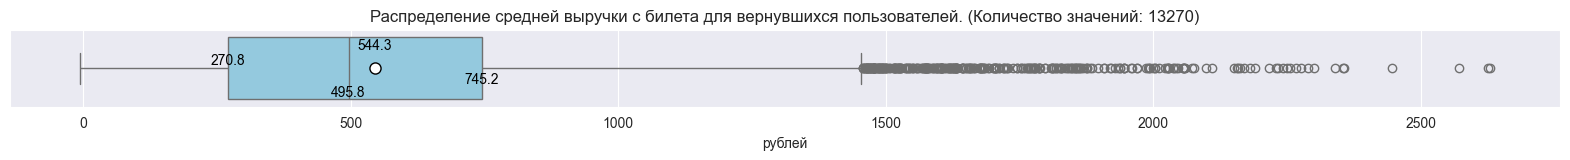

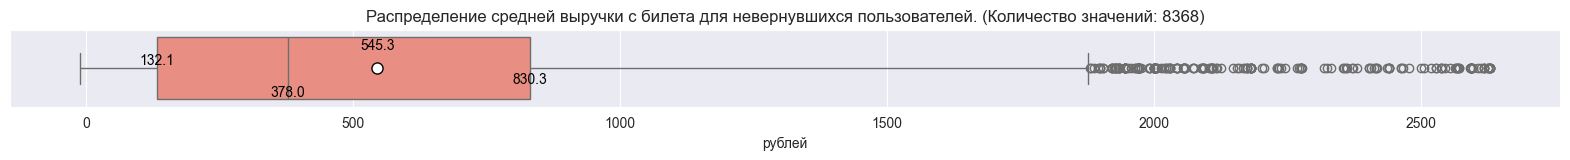

In [63]:
def boxplot_stat(row_series, name, xlabel, color="skyblue"):
    stats_is_two = {
                'mean': [row_series.mean(), -0.24],
                'median': [row_series.median(), 0.37],
                'q1': [row_series.quantile(0.25), -0.05],
                'q3': [row_series.quantile(0.75), 0.2]
            }
    plt.figure(figsize=(20, 1))
    ax = sns.boxplot(x=row_series, color=color, showmeans=True,
                            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
    for key, value in stats_is_two.items() :
                ax.text(value[0], value[1], f'{value[0]:.1f}',
                        horizontalalignment='center', size='medium', color='black', weight='light')
    plt.title(name + f" (Количество значений: {len(row_series)})")
    ax.set_xlabel(xlabel)
    plt.show()

df_is_two = user_profile[user_profile['is_two'] == True]['avg_revenue_ord']
df_isnot_two = user_profile[user_profile['is_two'] == False]['avg_revenue_ord']

boxplot_stat(df_is_two, 'Распределение средней выручки с билета для вернувшихся пользователей.', "рублей")
boxplot_stat(df_isnot_two, 'Распределение средней выручки с билета для невернувшихся пользователей.', "рублей", color='salmon')

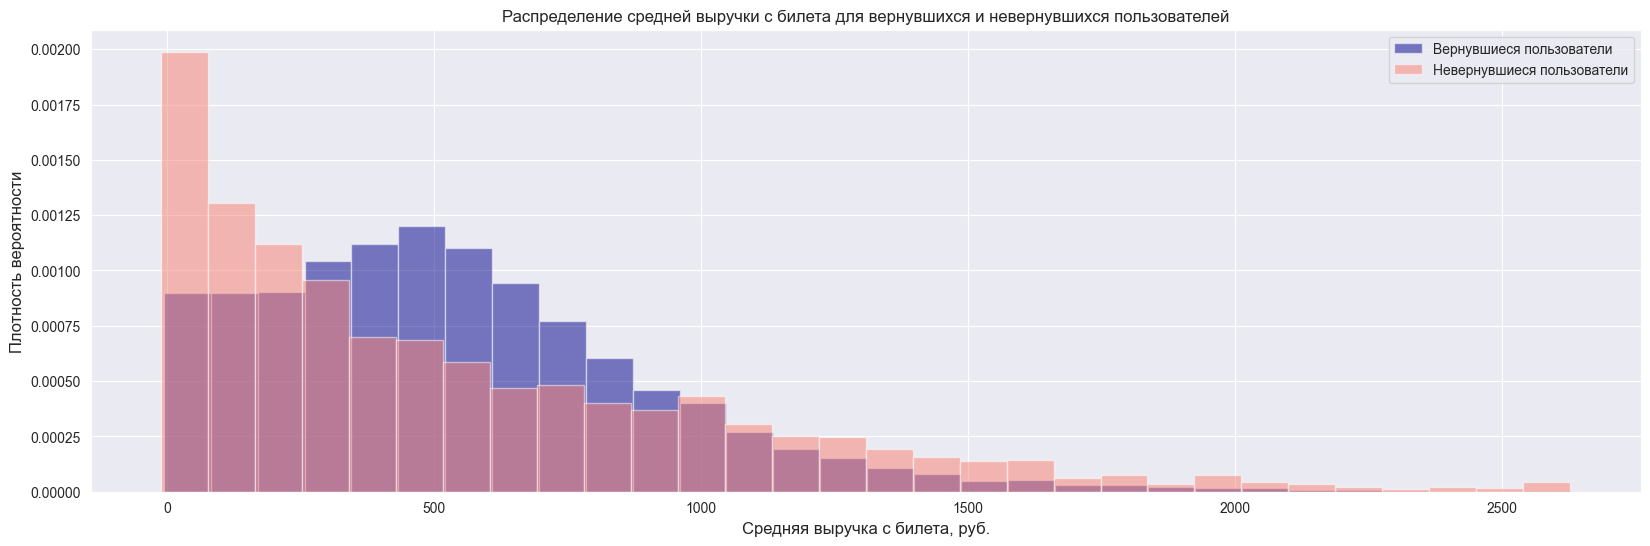

In [64]:
plt.figure(figsize=(20, 6))
plt.hist(x=df_is_two, label='Вернувшиеся пользователи', alpha=0.5, bins=30, density=True, color='darkblue') # darkorange
plt.hist(x=df_isnot_two, label='Невернувшиеся пользователи', alpha=0.5, bins=30, density=True, color='salmon') #darkblue
plt.title('Распределение средней выручки с билета для вернувшихся и невернувшихся пользователей', fontsize=12)
plt.xlabel('Средняя выручка с билета, руб.', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()
plt.show()

<h3> Промежуточный вывод: </h3>
- Пользователи с двумя и более заказами составляют большинство 60%. Распределение выручки в данном сегменте с 1 по 3 квартиль более определенное (чем у невернувшихся) и составляет от 270 до 830 рублей. Данная группа пользователей приносит большую выручку, по медианному значению, в 496 рублей.<br>
- Статистическое распределение средней выручки у невернувшихся пользователей более "размыто" в диапазоне с 1 по 3 квартиль от 132 до 830 рублей, что говорит о большем разнообразии в составе заказа и разнообразии потребностей пользователя относительно вернувшихся пользователей. Медианное значение выручки меньше и составляет 378 рублей.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


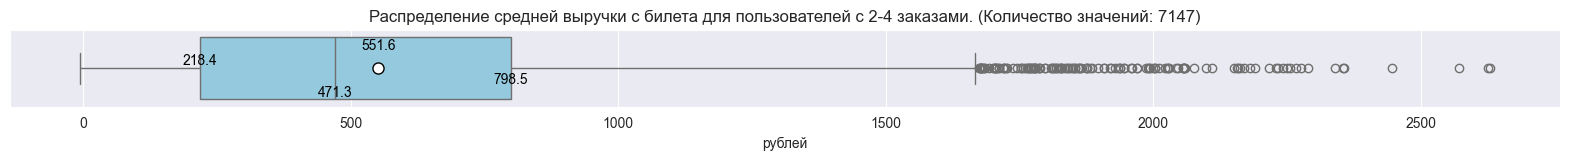

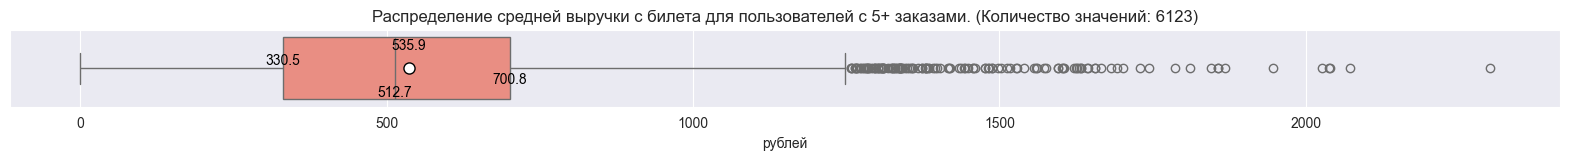

In [65]:
df_only_is_two = user_profile[(user_profile['is_two']==True) & (user_profile['is_five']==False)]['avg_revenue_ord']
df_is_five = user_profile[user_profile['is_five']==True]['avg_revenue_ord']
boxplot_stat(df_only_is_two, 'Распределение средней выручки с билета для пользователей с 2-4 заказами.', "рублей")
boxplot_stat(df_is_five, 'Распределение средней выручки с билета для пользователей с 5+ заказами.', "рублей", color='salmon')

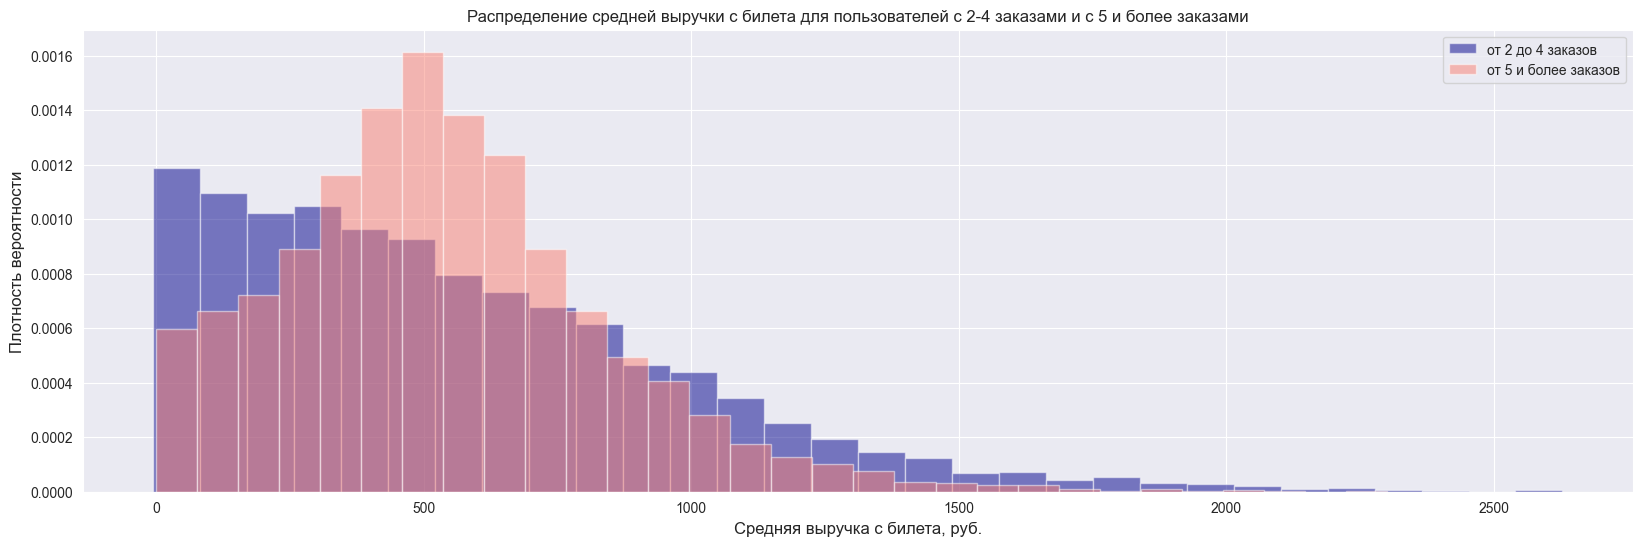

In [66]:
plt.figure(figsize=(20, 6))
plt.hist(x=df_only_is_two, label='от 2 до 4 заказов', alpha=0.5, bins=30, density=True, color='darkblue')
plt.hist(x=df_is_five, label='от 5 и более заказов', alpha=0.5, bins=30, density=True, color='salmon')
plt.title('Распределение средней выручки с билета для пользователей с 2-4 заказами и с 5 и более заказами', fontsize=12)
plt.xlabel('Средняя выручка с билета, руб.', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend()
plt.show()

<h3> Промежуточный вывод: </h3>
- Пользователи с 5 и более заказами составляют 25%. Распределение выручки в данном сегменте с 1 по 3 квартиль более определенное (чем у пользователей с 2-4 заказами) и составляет от 330 до 770 рублей. Данныая группа пользователей приносит большую выручку, по медианному значению, в 513 рублей. <br>
- Статистическое распределение средней выручки у пользователей c 2-4 заказами (которых по количеству 34%), более "размыто" в диапазоне с 1 по 3 квартиль от 218 до 798 рублей, что говорит о большем разнообразии в составе заказа и разнообразии потребностей пользователя относительно пользователей с 5 и более заказами. Медианное значение выручки меньше и составляет 417 рубль. <br>
- Наблюдается плавное увеличение медианной выручки с ростом количества заказов у пользователя.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

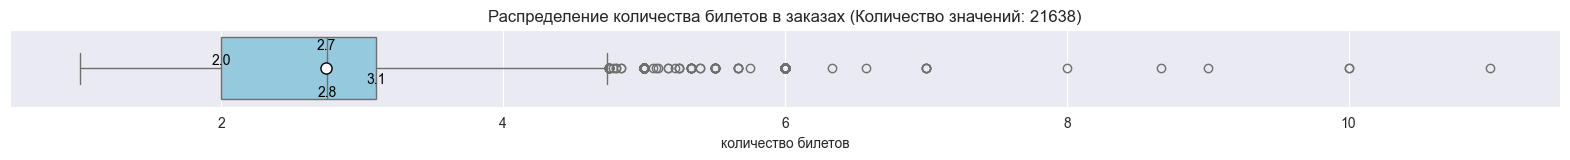

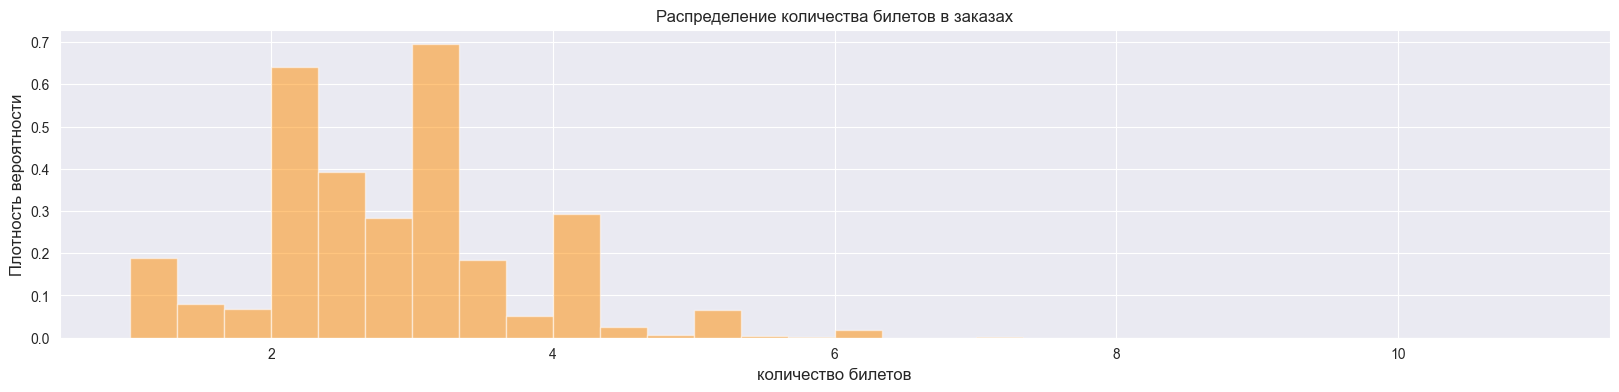

In [67]:
boxplot_stat(user_profile['avg_tickets_ord'], 'Распределение количества билетов в заказах', "количество билетов")

plt.figure(figsize=(20, 4))
plt.hist(x=user_profile['avg_tickets_ord'], label='avg_revenue_ord_only_is_two', alpha=0.5, bins=30, density=True, color='darkorange')
plt.title('Распределение количества билетов в заказах', fontsize=12)
plt.xlabel('количество билетов', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
#plt.legend()
plt.show()

По гистограмме распределения четко видно увеличение плотности в районе 2-3 билетов.

In [68]:
user_profile['cat_avg_ticket'] = pd.cut(
    user_profile['avg_tickets_ord'],
    bins=[1, 2, 3, 5, float('inf')],
    labels=['1 билет', '2 билета', '3-4 билета', 'от 5 билетов'],
    right=False  # левая граница включена, правая исключена, т.е. [1,2) -> '1 билет'
)

In [69]:
cat_avg_ticket_count = user_profile.groupby('cat_avg_ticket').agg(
    count=('user_id','count'),
    part_all=('user_id', lambda r: round(  ( r.count()/user_profile.shape[0])*100, 2) ),
    part_return=('is_two', lambda r: round(  ( r.sum()/r.count())*100, 2) )).reset_index()
cat_avg_ticket_count = cat_avg_ticket_count.rename(columns={
    'cat_avg_ticket':'категория_пользователя',
    'count': 'общее_количество',
    'part_all':'процент_от_общего',
    'part_return': 'процент_вернувшихся'})
cat_avg_ticket_count

,категория_пользователя,общее_количество,процент_от_общего,процент_вернувшихся
0,1 билет,2419,11.18,51.30
1,2 билета,9498,43.89,73.58
2,3-4 билета,9060,41.87,54.26
3,от 5 билетов,661,3.05,18.76


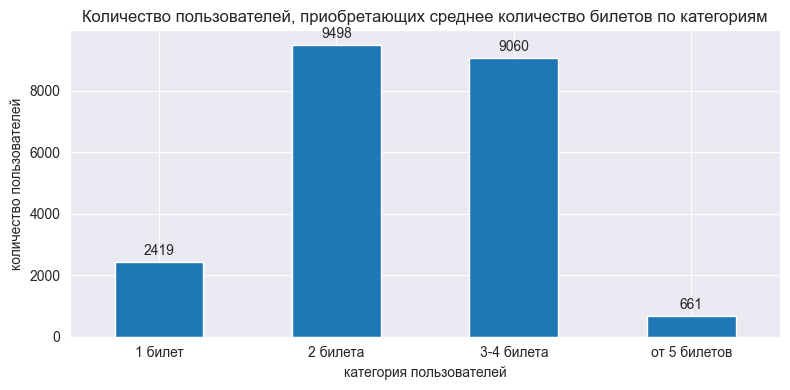

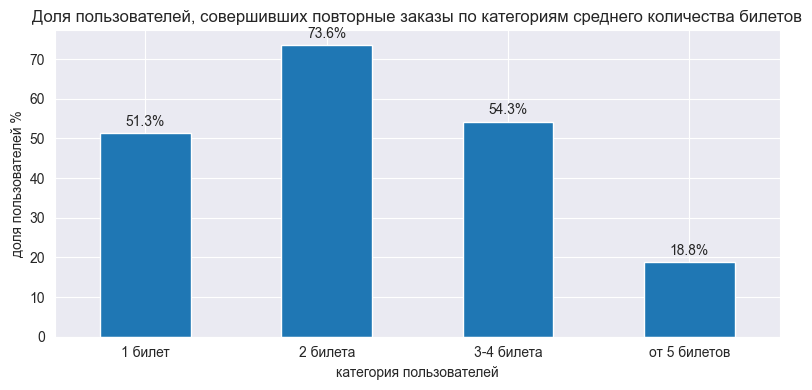

In [70]:

ax = cat_avg_ticket_count.plot(kind='bar', x='категория_пользователя', y='общее_количество',
                               title='Количество пользователей, приобретающих среднее количество билетов по категориям',
                               rot=0, figsize=(8, 4), legend=False,
                               xlabel='категория пользователей', ylabel='количество пользователей')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)  # fmt='%d' для целых чисел, padding – отступ от столбца

plt.tight_layout()
plt.show()


ax2 = cat_avg_ticket_count.plot(kind='bar', x='категория_пользователя', y='процент_вернувшихся',
                                title='Доля пользователей, совершивших повторные заказы по категориям среднего количества билетов',
                                rot=0, figsize=(8, 4), legend=False,
                                xlabel='категория пользователей', ylabel='доля пользователей %')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

Основная масса пользователей (84,6%) находится в двух сегментах: «2 билета» (43,3%) и «3–4 билета» (41,3%).

Сегмент «1 билет» – 11% пользователей.

Сегмент «от 5 билетов» – всего 3% пользователей.

________________________________________________________
«2 билета» – 73,6% возвращаются (самый высокий показатель).

«3–4 билета» – 54,3% (ниже среднего).

«1 билет» – 51,3% (ниже среднего).

«от 5 билетов» – 18,8% (очень низкий показатель).
______________________________________________________________
Выводы:

Пользователи, которые в среднем покупают 2 билета, наиболее лояльны – они возвращаются чаще всех.

Те, кто покупает 5 и более билетов, почти не возвращаются. Это, скорее всего, разовые групповые походы (компании, корпоративы).

Одиночные покупатели (1 билет) возвращаются реже, чем в среднем по выборке.
________________________________________________________________

Рекомендации:

Сосредоточить усилия на удержании сегмента «2 билета» – предлагать акции для пар, абонементы.

Стимулировать одиночек приводить друзей (скидка на второй билет), чтобы перевести их в более лояльную категорию.

На сегмент «от 5 билетов» не тратить много ресурсов на удержание – они и так почти не возвращаются.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [71]:
df_weekday = user_profile.copy()
df_weekday['first_order_date'] = pd.to_datetime(df_weekday['first_order_date'])

df_weekday['weekday'] = df_weekday['first_order_date'].dt.dayofweek

weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
df_weekday['weekday_name'] = df_weekday['weekday'].map(lambda x: weekday_names[x])

weekday_stats = df_weekday.groupby('weekday_name').agg(
    users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()
weekday_stats['return_rate_pct'] = weekday_stats['return_rate'] * 100


order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekday_stats['weekday_name'] = pd.Categorical(weekday_stats['weekday_name'], categories=order, ordered=True)
weekday_stats = weekday_stats.sort_values('weekday_name')

weekday_stats[['weekday_name', 'users', 'return_rate_pct']]

,weekday_name,users,return_rate_pct
2,Пн,2930,63.037543
1,Вт,3176,61.901763
5,Ср,3057,62.185149
6,Чт,3113,59.428204
3,Пт,3259,59.834305
4,Сб,3326,62.808178
0,Вс,2777,60.028808


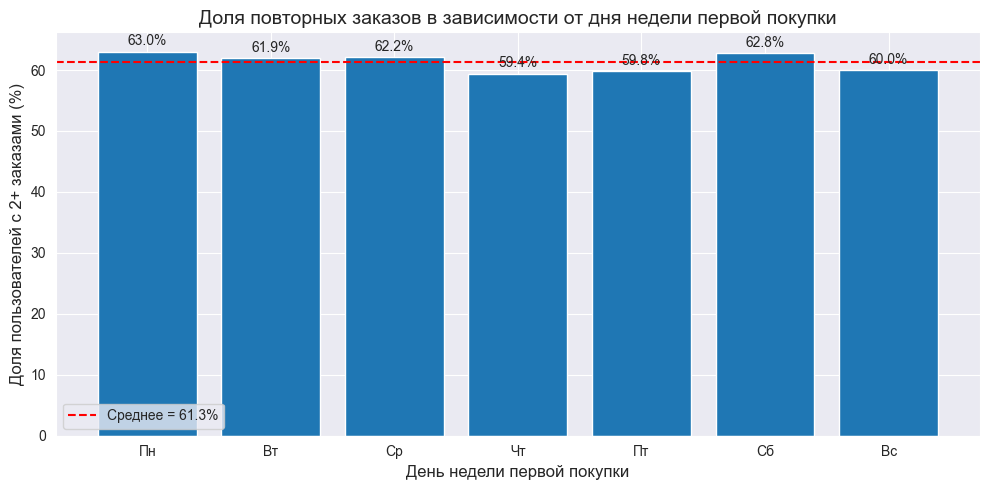

In [72]:
plt.figure(figsize=(10, 5))
bars = plt.bar(weekday_stats['weekday_name'], weekday_stats['return_rate_pct'])
plt.title('Доля повторных заказов в зависимости от дня недели первой покупки', fontsize=14)
plt.xlabel('День недели первой покупки', fontsize=12)
plt.ylabel('Доля пользователей с 2+ заказами (%)', fontsize=12)
plt.axhline(y=user_profile['is_two'].mean()*100, color='red', linestyle='--', label=f'Среднее = {user_profile["is_two"].mean()*100:.1f}%')
plt.legend()

# Подписи на столбцах
for bar, val in zip(bars, weekday_stats['return_rate_pct']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

День недели влияет на возврат пользователя, но не очень сильно. Разница между лучшим и худшим днём составляет 3.6 % (от 59.4% до 63.0%). Понедельник и суббота самые благоприятные дни в этой ситуации

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [73]:
# Берём только пользователей с повторными заказами (is_two = True)
repeat_users = user_profile[user_profile['is_two'] == True].copy()

# Создаём группы по количеству заказов
repeat_users['order_group'] = repeat_users['total_ord'].apply(
    lambda x: '2-4 заказа' if x <= 4 else '5+ заказов'
)

# Статистика по интервалам
interval_stats = repeat_users.groupby('order_group')['time_between_ord'].agg(['count', 'mean', 'median', 'std'])
interval_stats = interval_stats.rename(columns={'count': 'количество', 'mean': 'среднее', 'median': 'медиана', 'std': 'std'})
print(interval_stats)

             количество    среднее  медиана        std
order_group                                           
2-4 заказа         7147  21.296488      9.0  28.554397
5+ заказов         6123   9.555447      8.0   7.834284


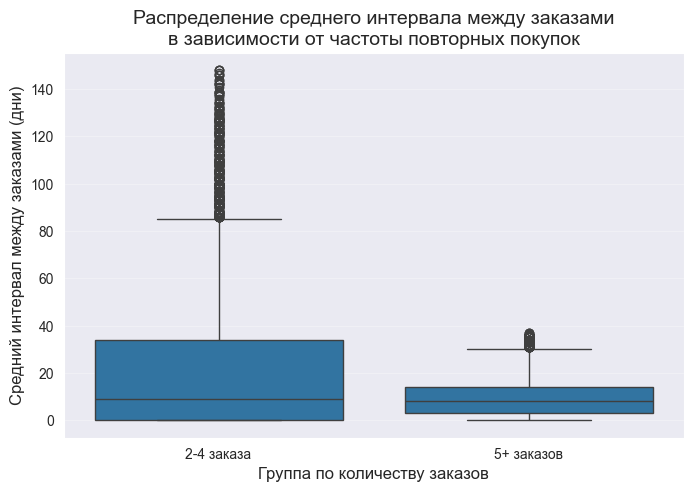

In [74]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=repeat_users, x='order_group', y='time_between_ord')
plt.title('Распределение среднего интервала между заказами\nв зависимости от частоты повторных покупок', fontsize=14)
plt.xlabel('Группа по количеству заказов', fontsize=12)
plt.ylabel('Средний интервал между заказами (дни)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

Медианные интервалы почти одинаковы (9 дней vs 8 дней) – типичный пользователь в обеих группах возвращается примерно раз в 1–1.5 недели.

Средние интервалы сильно различаются (21.3 vs 9.6) из-за того, что в группе 2–4 заказа есть много пользователей с очень большими интервалами (выбросы до сотен дней), которые «тянут» среднее вверх.

Стандартное отклонение в группе 5+ заказов в 3.6 раза меньше – их интервалы более стабильны и предсказуемы.

Короткие и стабильные интервалы между заказами – признак высокой лояльности и предсказуемости поведения.
Пользователи, которые возвращаются быстро (в течение 1–2 недель) и регулярно, с большей вероятностью совершат 5 и более заказов.
Пользователи с большими и хаотичными интервалами редко переходят за 4 заказа.

Важно сокращать интервал между первым и вторым заказом. Если пользователь возвращается в течение 7–10 дней, он с высокой вероятностью станет постоянным (5+ заказов).

Пользователи с интервалом более 30 дней – рискованные; они могут «отвалиться» после 2–3 заказов.

Сегмент «5+ заказов» – самый ценный: они возвращаются быстро и регулярно. Их нужно поощрять программами лояльности, чтобы удержать ещё дольше.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [75]:
df_corr = user_profile.copy()

features = ['total_ord', 'avg_revenue_ord', 'avg_tickets_ord',
            'time_between_ord', 'device', 'first_event', 'region', 'service']
df_corr = df_corr[features]


In [76]:
phi_matrix = df_corr.phik_matrix(interval_cols=['total_ord', 'avg_revenue_ord', 'avg_tickets_ord', 'time_between_ord'])
phi_matrix.round(2)

,total_ord,avg_revenue_ord,avg_tickets_ord,time_between_ord,device,first_event,region,service
total_ord,1.00,0.22,0.23,0.29,0.03,0.03,0.11,0.03
avg_revenue_ord,0.22,1.00,0.46,0.10,0.08,0.33,0.36,0.38
avg_tickets_ord,0.23,0.46,1.00,0.10,0.06,0.10,0.16,0.07
time_between_ord,0.29,0.10,0.10,1.00,0.02,0.05,0.08,0.05
device,0.03,0.08,0.06,0.02,1.00,0.06,0.12,0.08
first_event,0.03,0.33,0.10,0.05,0.06,1.00,0.51,0.59
region,0.11,0.36,0.16,0.08,0.12,0.51,1.00,0.70
service,0.03,0.38,0.07,0.05,0.08,0.59,0.70,1.00


<Figure size 1000x800 with 0 Axes>

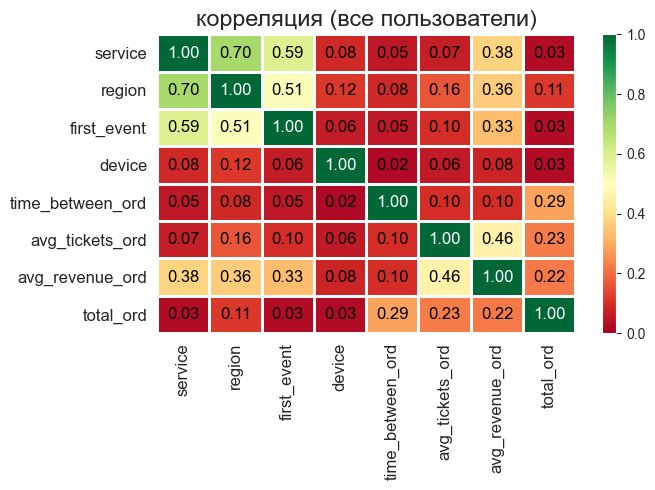

In [77]:
plt.figure(figsize=(10, 8))
plot_correlation_matrix(phi_matrix.values,
                        x_labels=phi_matrix.columns,
                        y_labels=phi_matrix.index,
                        vmin=0, vmax=1,
                        title='корреляция (все пользователи)',
                        fontsize_factor=1.2)
plt.tight_layout()
plt.show()

C:\Users\med-s\Desktop\YandexAfisha\.venv\Lib\site-packages\phik\data_quality.py:72: UserWarning: Not enough unique value for variable time_between_ord for analysis 0. Dropping this column
  warnings.warn(


<Figure size 800x600 with 0 Axes>

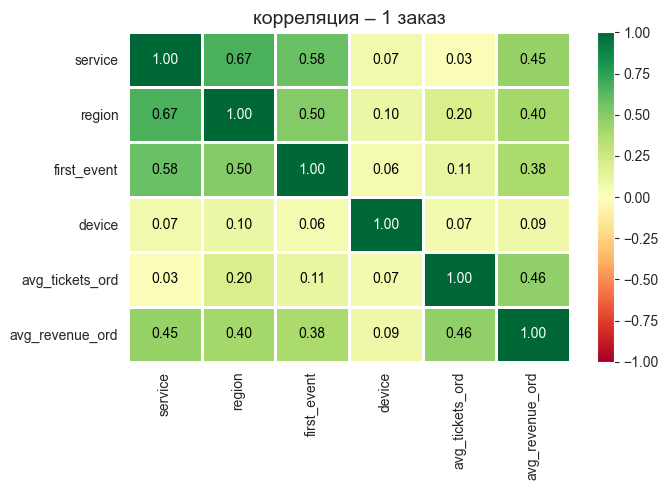

<Figure size 800x600 with 0 Axes>

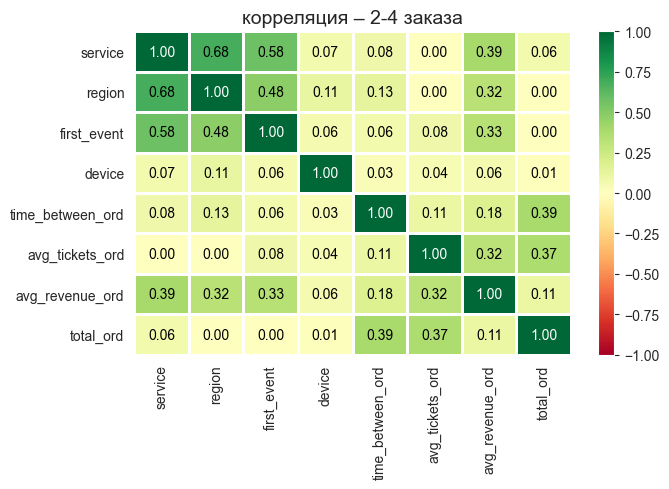

<Figure size 800x600 with 0 Axes>

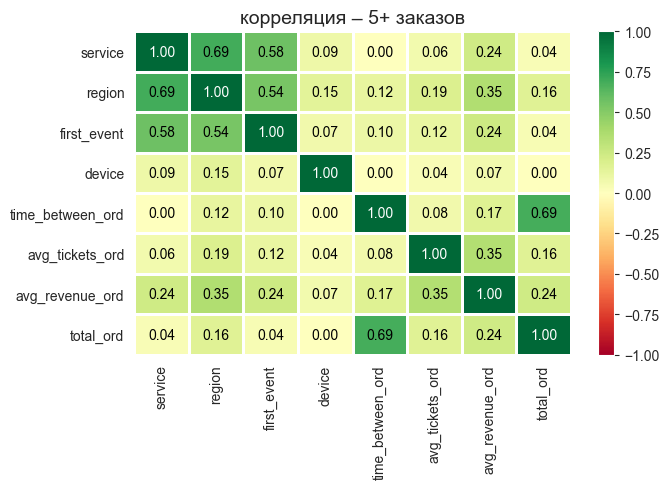

In [78]:
# Создаём сегменты
df_corr['total_ord_segment'] = pd.cut(df_corr['total_ord'],
                                      bins=[0, 1, 4, float('inf')],
                                      labels=['1 заказ', '2-4 заказа', '5+ заказов'])

# Для каждого сегмента строим корреляцию с total_ord (или без него)
segments = ['1 заказ', '2-4 заказа', '5+ заказов']
for seg in segments:
    subset = df_corr[df_corr['total_ord_segment'] == seg].copy()

    subset = subset.drop(columns=['total_ord_segment'])

    if seg == '1 заказ':
        subset = subset.drop(columns=['total_ord'])


        if subset.shape[1] > 1:
            phi_sub = subset.phik_matrix(interval_cols=['avg_revenue_ord', 'avg_tickets_ord', 'time_between_ord'])
            plt.figure(figsize=(8,6))
            plot_correlation_matrix(phi_sub.values, x_labels=phi_sub.columns, y_labels=phi_sub.columns,
                                    title=f'корреляция – {seg}')
            plt.show()
    else:

        phi_sub = subset.phik_matrix(interval_cols=['total_ord', 'avg_revenue_ord', 'avg_tickets_ord', 'time_between_ord'])

        corr_with_total = phi_sub['total_ord'].sort_values(ascending=False)

        # Тепловая карта полной матрицы
        plt.figure(figsize=(8,6))
        plot_correlation_matrix(phi_sub.values, x_labels=phi_sub.columns, y_labels=phi_sub.columns,
                                title=f'корреляция – {seg}')
        plt.show()

Главный фактор – средний интервал между заказами (time_between_order).

Чем быстрее пользователь возвращается, тем больше заказов он делает.

Особенно сильно это проявляется в сегменте 5+ заказов (0.69) – там короткий интервал критичен для перехода к 10, 20 заказам.

Второй фактор – среднее количество билетов в заказе (avg_tickets_order).

В сегменте 2–4 заказа он почти так же важен, как интервал (0.37).

В сегменте 5+ заказов его влияние снижается (0.16) – вероятно, потому что все в этом сегменте уже покупают ~2 билета, и дальнейшая дифференциация слаба.

Третий фактор – средняя выручка (avg_revenue_order) – даёт небольшой вклад (0.11–0.24), часто через связь с количеством билетов.

Регион, сервис, тип первого мероприятия, устройство – практически не коррелируют с total_order (значения 0.00–0.16, чаще 0.00–0.06). То есть, зная регион или оператора, нельзя предсказать, сколько заказов сделает пользователь.

Ключевой драйвер роста числа заказов – сокращение времени между покупками; оптимальное количество билетов – 2; регион и оператор почти не влияют.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

<h3>О данных и подготовке</h3>
Исходные данные – выгрузка из SQL за период, содержащая ~291 тыс. покупок. После объединения с событиями, городами и регионами получили датафрейм с информацией о пользователях, заказах, выручке, билетах.

Подготовка:

Конвертация выручки: для заказов в тенге (currency_code = 'kzt') пересчитали в рубли по курсу на дату из csv файла. Для рублей выручку оставили как есть.


Отфильтрованы выбросы по revenue_rub (99‑й перцентиль ≈ 2628 руб) и по числу заказов на пользователя (total_ord > 152, т.к. встречались аномалии до 10 тыс. заказов – вероятно, тестовые аккаунты).

Создан профиль пользователя (user_profile), включающий: даты первого и последнего заказа, устройство, регион, сервис, тип первого мероприятия, общее число заказов, среднюю выручку и среднее число билетов, средний интервал между заказами, флаги is_two (≥2 заказов) и is_five (≥5 заказов).


<h3>Основные результаты анализа</h3>
<h4>Объём выборки</h4>
После фильтрации в профиле осталось 21 638 пользователей. Из них:

8 368 (38.7%) совершили только один заказ.

13 270 (61.3%) совершили 2 и более заказов.

6 123 (28.3%) – 5 и более заказов (наиболее лояльные).

Распределение по числу заказов сильно скошено вправо: большинство пользователей имеют 2–4 заказа, но есть и «супер-пользователи» с десятками заказов. Медианное число заказов – 3.

<h4>Какие признаки первого заказа связаны с возвратом?</h4>

Тип мероприятия: лидеры – концерты (44% пользователей, возврат 61,8%), театр (63,4%), выставки (64,0%). Спорт и ёлки – аутсайдеры (55,8%).

Устройство: мобильные устройства доминируют (82,9% первых покупок), но десктопные пользователи возвращаются чаще (63,8% против 60,8%).

Регион: самые высокие возвраты в Шанырском регионе (67,2%) и Светополянском округе (65,6%). Крупнейший регион (Каменевский) показывает 62,4% – чуть выше среднего.

Билетный оператор: лидеры по возвратам – «Край билетов» (65,2%) и «Дом культуры» (64,6%), при этом крупнейший оператор «Билеты без проблем» даёт 60,4%.

<h4>Средняя выручка и количество билетов</h4>

У вернувшихся пользователей медианная средняя выручка на заказ заметно выше: 496 руб против 378 руб у тех, кто сделал только один заказ.

Количество билетов – сильный предиктор: сегмент «2 билета» показывает 73,6% возвратов (наилучший), тогда как сегмент «5+ билетов» – лишь 18,8% (аномально низкий). Пользователи с 1 билетом возвращаются в 51,3% случаев.

<h4>Временные характеристики</h4>

День недели первой покупки незначительно влияет на возврат: лучшие дни – понедельник (63,0%) и суббота (62,8%); худшие – четверг (59,4%) и пятница (59,8%).

Средний интервал между заказами – ключевой фактор удержания. У пользователей с 5+ заказами медианный интервал 8 дней, у группы 2–4 заказа – 9 дней. Корреляция time_between_ord с числом заказов очень высока: в сегменте 5+ заказов  = 0,69, в сегменте 2–4 заказа – 0,39.

<h4>Корреляционный анализ </h4>

Наибольшее влияние на общее число заказов оказывают:

Средний интервал между заказами (0,29 в общей выборке, 0,39–0,69 в сегментах)

Среднее количество билетов (0,23 в общем, 0,37 в сегменте 2–4)

Средняя выручка коррелирует слабо (0,22), а регион, тип мероприятия, устройство и оператор практически не связаны с числом заказов (значения 0,00–0,11).

<h4>Дополнительные важные наблюдения</h4>
Пользователи, покупающие ровно 2 билета (вероятно, пары), – самый ценный сегмент: они и возвращаются чаще, и делают больше заказов.

Групповые покупки (5+ билетов) – разовые, такие пользователи почти не возвращаются.

Короткие интервалы (менее 10 дней) – маркер перехода в категорию «супер-лояльных» (5+ заказов).

Региональные и операторские различия важны для выбора мероприятий, но не предсказывают повторные покупки.

<h3>Рекомендации заказчику</h3>
1. Сфокусироваться на сокращении интервала между заказами<br>
Запустить автоматические напоминания через 5–7 дней после первого заказа с персонализированной подборкой мероприятий на ближайшие выходные.
Внедрить программу лояльности: бонусы или скидку на следующий заказ, если он сделан в течение 7 дней.
Для пользователей, у которых интервал превысил 14 дней, использовать реактивационные кампании (купоны, специальные предложения). <br>

2. Стимулировать покупку 2 билетов<br>
Акции «приведи друга» – скидка на второй билет.
Абонементы на двоих для театров и концертов.
Целевые коммуникации для сегмента «1 билет»: «Купите ещё один билет со скидкой 20%» – это может перевести их в более лояльную категорию. <br>
3. Усилить работу с десктопными пользователями<br>
Десктопные клиенты составляют лишь 17% аудитории, но их возврат выше на 3 п.п. Возможно, они более «плановые». Стоит улучшить десктопную версию сайта, добавить удобные календари и рекомендации.<br>
4. Обратить внимание на проблемные сегменты<br>
Спорт и ёлки – низкий возврат. Для них нужны специальные механики: например, после спортивного мероприятия – предложение билетов на следующую игру со скидкой.
Покупки 5+ билетов – не тратить ресурсы на удержание; вместо этого можно предложить им скидку на следующий групповой заказ сразу при оформлении, но не ждать повторения.<br>
5. Использовать «лучшие дни» для первого заказа<br>
При планировании рекламных кампаний для привлечения новых пользователей отдавать приоритет понедельнику и субботе – пользователи, пришедшие в эти дни, более лояльны.<br>
6. Не переоценивать региональную и операторную сегментацию<br>
Регион и билетный оператор почти не влияют на повторные заказы. Не стоит строить сложные маркетинговые программы на их основе – лучше инвестировать в сокращение интервалов и стимулирование покупки пар билетов.<br>


### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**
https://github.com/obitatel/afisha